---
title: "Merton Heston"
subtitle: "Soporte Metodologico"
author:   
    - name: "Equipo quantis"
date: "2026-05-10"
format:
  html:
    html-math-method: mathml
    toc: true
    toc-depth: 3
    toc-location: right
    toc-title: "Contenido"
    self-contained: true
  pdf:
    toc: true
    toc-depth: 3
    toc-title: "Contenido"
number-sections: true
---


# Estrategias de trading con opciones

# Greek Black-Scholes

In [61]:
# import subprocess, sys
# subprocess.run([sys.executable, "-m", "pip", "install", "plotly", "seaborn", "-q"], check=True)

In [62]:
import pandas as pd
import numpy as np

from pathlib import Path

from scipy.interpolate import LinearNDInterpolator, NearestNDInterpolator, interp1d
from scipy.optimize import brentq

from scipy.stats import norm

import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns

In [63]:
df_bs = pd.DataFrame({
    "fecha_obs": ["22-ene", "29-ene", "05-feb", "10-feb", "17-feb", "19-feb", "24-feb", "26-feb", "05-mar", "17-mar", "19-mar", "25-mar", "26-mar"],
    "fecha_venc": ["09-abr"] * 13,
    "dias_restantes": [77, 70, 63, 58, 51, 49, 44, 42, 35, 23, 21, 15, 14],
    "mes_idx": [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
    "S": [234.34, 241.73, 222.69, 206.96, 201.15, 204.44, 208.56, 207.92, 218.94, 213.50, 209.18, 211.71, 207.54],
    "T": [0.211, 0.192, 0.173, 0.159, 0.140, 0.134, 0.121, 0.115, 0.096, 0.063, 0.058, 0.041, 0.038],
    "sigma": [0.3046, 0.2990, 0.2748, 0.3022, 0.2893, 0.2857, 0.2902, 0.2871, 0.2929, 0.2886, 0.2884, 0.2940, 0.2945],
    "r_cont": [0.0417] * 13,
})

meses_es = {
    "ene": 1,
    "feb": 2,
    "mar": 3,
    "abr": 4,
    "may": 5,
    "jun": 6,
    "jul": 7,
    "ago": 8,
    "sep": 9,
    "oct": 10,
    "nov": 11,
    "dic": 12,
}

def parse_fecha_es(fecha_str, year=2026):
    dia, mes = fecha_str.strip().lower().split("-")
    return pd.Timestamp(year=year, month=meses_es[mes], day=int(dia))

df_bs["fecha_obs"] = df_bs["fecha_obs"].apply(parse_fecha_es)
df_bs["fecha_venc"] = df_bs["fecha_venc"].apply(parse_fecha_es)

df_bs.set_index("fecha_obs")

,fecha_venc,dias_restantes,mes_idx,S,T,sigma,r_cont
fecha_obs,,,,,,,
2026-01-22,2026-04-09,77,0,234.34,0.211,0.3046,0.0417
2026-01-29,2026-04-09,70,1,241.73,0.192,0.2990,0.0417
2026-02-05,2026-04-09,63,2,222.69,0.173,0.2748,0.0417
2026-02-10,2026-04-09,58,3,206.96,0.159,0.3022,0.0417
2026-02-17,2026-04-09,51,4,201.15,0.140,0.2893,0.0417
2026-02-19,2026-04-09,49,5,204.44,0.134,0.2857,0.0417
2026-02-24,2026-04-09,44,6,208.56,0.121,0.2902,0.0417
2026-02-26,2026-04-09,42,7,207.92,0.115,0.2871,0.0417
2026-03-05,2026-04-09,35,8,218.94,0.096,0.2929,0.0417


In [64]:
df_K = pd.DataFrame({
    "K": [140.00, 170.00, 195.00, 212.50, 227.50, 235.00, 252.50, 270.00, 280.00, 290.00, 300.00]
})

In [65]:
def bs_d1(S, K, r, sigma, T, q=0.0):
    S, K, r, sigma, T, q = map(np.asarray, (S, K, r, sigma, T, q))
    return (np.log(S / K) + (r - q + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

def bs_d2(S, K, r, sigma, T, q=0.0):
    return bs_d1(S, K, r, sigma, T, q) - sigma * np.sqrt(T)

def bs_call_price(S, K, r, sigma, T, q=0.0):
    d1 = bs_d1(S, K, r, sigma, T, q)
    d2 = bs_d2(S, K, r, sigma, T, q)
    return S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def calc_count_int(M : float, r: float, T : float) -> float:
    return M * np.exp(r * T)


In [66]:
def call_premium_table(df_bs, df_K, q=0.0, time_col="fecha_obs"):
    base = (
        df_bs.assign(
            fecha_label=lambda x: pd.to_datetime(x[time_col]).map(
                lambda d: f"{d.year}-{d.month}-{d.day}"
            )
        )[["fecha_label", "S", "T", "sigma", "r_cont"]]
        .rename(columns={"fecha_label": "fecha"})
    )

    return (
        base.merge(df_K[["K"]], how="cross")
        .assign(
            call_price=lambda x: bs_call_price(
                S=x["S"],
                K=x["K"],
                r=x["r_cont"],
                sigma=x["sigma"],
                T=x["T"],
                q=q,
            )
        )
        .pivot(index="K", columns="fecha", values="call_price")
        .sort_index()
        .round(2)
    )


In [67]:
tabla_primas = call_premium_table(df_bs, df_K)
tabla_primas.iloc[:, 0] = [123.80, 90.87, 66.60, 42.45, 22.05, 14.50, 4.85, 1.63, 0.76, 0.70 ,0.33]
tabla_primas

fecha,2026-1-22,2026-1-29,2026-2-10,2026-2-17,2026-2-19,2026-2-24,2026-2-26,2026-2-5,2026-3-17,2026-3-19,2026-3-25,2026-3-26,2026-3-5
K,,,,,,,,,,,,,
140.0,123.80,102.85,67.89,61.97,65.22,69.26,68.59,83.70,73.87,69.52,71.95,67.76,79.50
170.0,90.87,73.11,38.51,32.59,35.65,39.55,38.85,53.97,43.95,39.60,42.00,37.81,49.63
195.0,66.60,48.80,17.66,12.66,14.61,17.36,16.61,30.36,19.70,15.72,17.48,13.62,25.53
212.5,42.45,33.18,8.11,4.74,5.66,7.10,6.48,16.82,6.96,4.54,4.82,2.84,11.97
227.5,22.05,21.87,3.53,1.64,1.99,2.58,2.22,8.71,1.78,0.90,0.76,0.31,4.81
235.0,14.50,17.17,2.21,0.89,1.09,1.43,1.18,5.93,0.76,0.32,0.23,0.07,2.76
252.5,4.85,8.95,0.64,0.18,0.22,0.29,0.22,2.10,0.07,0.02,0.01,0.00,0.59
270.0,1.63,4.12,0.16,0.03,0.04,0.05,0.03,0.61,0.00,0.00,0.00,0.00,0.09
280.0,0.76,2.51,0.07,0.01,0.01,0.01,0.01,0.28,0.00,0.00,0.00,0.00,0.03


In [68]:
tabla_primas.sum(axis = 0)

fecha
2026-1-22    368.54
2026-1-29    314.88
2026-2-10    138.82
2026-2-17    114.71
2026-2-19    124.49
2026-2-24    137.63
2026-2-26    134.19
2026-2-5     202.65
2026-3-17    147.09
2026-3-19    130.62
2026-3-25    137.25
2026-3-26    122.41
2026-3-5     174.92
dtype: float64

## With out strategies

En este ejercicio consideraremos una estretegia donde no consideran estrategias de convertura para cubrir los movimientos de la cartarea.

Por tanto considerando que tomamos una posición short sobre financial options call tenemos que a nosotro nos pagan una cantidad de

In [69]:
total_primes = tabla_primas.iloc[:, 0].sum()
total_primes

np.float64(368.53999999999996)

En primas por la venta de las opciones

Considerando lo anterior, si evaluamos cuales de las opciones terminaron in the mony al final del tiempo $T$ tenemos que

In [70]:
df_bs.iloc[-1]["S"] > df_K

,K
0,True
1,True
2,True
3,False
4,False
5,False
6,False
7,False
8,False
9,False


3 de las 10 opciones se habrian ejersido y por tanto tendriamos que comprar el activo al precio spot y venderlo al precio strike, en ste sentido

In [71]:
stock_sell = df_K[df_bs.iloc[-1]["S"] > df_K]
stock_sell = stock_sell.fillna(0)
stock_sell

,K
0,140.0
1,170.0
2,195.0
3,0.0
4,0.0
5,0.0
6,0.0
7,0.0
8,0.0
9,0.0


In [72]:
# Resultado neto
total_primes_invest = calc_count_int(M = total_primes, r = df_bs.loc[0, "r_cont"], T=df_bs.loc[0, "T"])

result_tradeoff = total_primes_invest + (stock_sell.sum() - df_bs.iloc[-1]["S"] * 3)

Por tanto nuestra ganancia perdida por esta estrategia se encuentra en

In [73]:
result_tradeoff

K    254.17698
dtype: float64

# Delta Hedging

## Theory

Como ya sabemo la dinamica de un portafolio $\Pi$ esta dado por su diferencial $d\Pi$ por tanto si consideramos el modelo

$$
d\Pi = Q_1dS_t + Q_2dc(S_t, t)
$$

tenemos que con una simple apliación el lema de Itô para $c(S_t,t)$:

$$
dc(S_t,t) =
\frac{\partial c}{\partial t}dt +
\frac{\partial c}{\partial S_t}dS_t +
\frac{1}{2}\sigma^2 S_t^2 \frac{\partial^2 c}{\partial S_t^2}dt
$$

Sustituyendo en $d\Pi_t$:

$$
d\Pi_t =
Q_1\, dS_t +
Q_2\left(
\frac{\partial c}{\partial t},dt +
\frac{\partial c}{\partial S_t}\,dS_t +
\frac{1}{2}\sigma^2 S_t^2 \frac{\partial^2 c}{\partial S_t^2}\,dt
\right)
$$

Obtenemos la forma factorizada por diferenciales:

$$
d\Pi_t =
\left(
Q_1 + Q_2 \frac{\partial c}{\partial S_t}
\right)dS_t
+
Q_2\left(
\frac{\partial c}{\partial t}
+
\frac{1}{2}\sigma^2 S_t^2 \frac{\partial^2 c}{\partial S_t^2}
\right)dt
$$

La cual en este punto deja bastante claro cuales son los terminos que determinan el grado de incertidumbre incorporado en el modelo. Por tanto si $dS_t$ es la parte del modelo que incorpora el riesgo o la incetidumbre en el mismo por ser proceso estocastico deberiamos de tratar de definir cantidades de $Q_1$ y $Q_2$ de tal manera que podamos eliminar este termino estocastico.

Aquí es donde justamente se incorpora la idea del **delta hedging** la cual es tomar $Q_1$ y $Q_2$ de tal manera que el factor de incertidumbre $dS_t$ pueda ser eliminado.

El término estocástico está dado por

$$
\left(
Q_1 + Q_2 \frac{\partial c}{\partial S_t}
\right)dS_t
$$

Por lo tanto, para eliminar la incertidumbre se impone la condición de **neutralidad delta**:

$$
Q_1 + Q_2 \frac{\partial c}{\partial S_t} = 0
$$

de donde

$$
Q_1 = - Q_2 \frac{\partial c}{\partial S_t}
$$

Sustituyendo esta elección en $d\Pi_t$, el término en $dS_t$ se neutraliza (elimina) y se obtiene un portafolio delta-neutral:

$$
d\Pi_t^{(\Delta)} =
Q_2\left(
\frac{\partial c}{\partial t}
+
\frac{1}{2}\sigma^2 S_t^2 \frac{\partial^2 c}{\partial S_t^2}
\right)dt
$$

Es decir, el diferencial del portafolio ya no depende de $dS_t$, sino únicamente de $dt$, por lo que queda localmente libre de riesgo.


Por tanto nuestra estrategía donde si $Q_2 = -1$ consisten en determinar la cantidad

$$
Q_1 = \frac{\partial c}{\partial S_t}
$$

De esta forma ahora nuestro segundo problema se encuentra en determinar como podemos calcular el $\Delta$ de un portafolio de opciones

Para ello, si consideramos que el valor de un call $C(S_t, t)$ está dado por

$$
C(S_t, t) = N(d_1)S_t - Ke^{-r(T-t)}N(d_2)
$$

donde

$$
d_1 = \frac{\ln\left(\frac{S_t}{K}\right) + \left(r+\frac{1}{2}\sigma^2\right)(T-t)}{\sigma\sqrt{T-t}}
\qquad \text{y} \qquad
d_2 = d_1 - \sigma\sqrt{T-t},
$$

el cálculo de la parcial de $C(S_t, t)$ respecto de $S_t$ se obtiene aplicando la regla del producto y la regla de la cadena:

$$
\Delta_{call} = \frac{\partial C}{\partial S_t} =
\frac{\partial}{\partial S_t}\left(S_tN(d_1)\right) -
\frac{\partial}{\partial S_t}\left(Ke^{-r(T-t)}N(d_2)\right)
$$

Como $Ke^{-r(T-t)}$ es constante respecto de $S_t$, entonces

$$
\frac{\partial C}{\partial S_t} =
N(d_1) + S_t N'(d_1)\frac{\partial d_1}{\partial S_t} -
Ke^{-r(T-t)}N'(d_2)\frac{\partial d_2}{\partial S_t}
$$

donde $N'(x)=\phi(x)$, con $\phi(x)$ la densidad de la normal estándar.

Ahora, como

$$
\frac{\partial d_1}{\partial S_t} =
\frac{1}{S_t\sigma\sqrt{T-t}}
\qquad \text{y} \qquad
\frac{\partial d_2}{\partial S_t} =
\frac{1}{S_t\sigma\sqrt{T-t}},
$$

se tiene

$$
\frac{\partial C}{\partial S_t} =
N(d_1) +
S_t\phi(d_1)\frac{1}{S_t\sigma\sqrt{T-t}} -
Ke^{-r(T-t)}\phi(d_2)\frac{1}{S_t\sigma\sqrt{T-t}}
$$

es decir,

$$
\frac{\partial C}{\partial S_t} =
N(d_1) +
\frac{\phi(d_1)}{\sigma\sqrt{T-t}} -
\frac{Ke^{-r(T-t)}\phi(d_2)}{S_t\sigma\sqrt{T-t}}
$$

Utilizando la identidad

$$
S_t\phi(d_1)=Ke^{-r(T-t)}\phi(d_2),
$$

los dos últimos términos se cancelan, por lo que finalmente se obtiene

$$
\frac{\partial C}{\partial S_t}=N(d_1)
$$

Por lo tanto, la delta de un call europeo en el modelo de Black-Scholes es

$$
\Delta_{call} = \frac{\partial C}{\partial S_t}=N(d_1)
$$


## Code

In [74]:
# Calculo de la delta de un call para cada combinacion fecha-strike
def bs_call_delta(S, K, r, sigma, T, q=0.0):
    d1 = bs_d1(S, K, r, sigma, T, q)
    return np.exp(-q * T) * norm.cdf(d1)

def call_delta_table(df_bs, df_K, q=0.0, time_col="fecha_obs", include_details=False):
    # 1. Variables de entrada del modelo en cada fecha.
    base = df_bs[[time_col, "S", "T", "sigma", "r_cont"]].copy()
    base["fecha"] = pd.to_datetime(base[time_col])

    # 2. Una fila por cada combinacion de fecha y strike.
    delta_long = base.merge(df_K[["K"]], how="cross")

    # 3. Calculo explicito de d1 y de la delta del call.
    delta_long["d1"] = bs_d1(
        S=delta_long["S"],
        K=delta_long["K"],
        r=delta_long["r_cont"],
        sigma=delta_long["sigma"],
        T=delta_long["T"],
        q=q,
    )
    
    delta_long["delta_call"] = np.exp(-q * delta_long["T"]) * norm.cdf(delta_long["d1"])

    # 4. Tabla final: strikes en filas y fechas en columnas, en orden cronologico real.
    tabla_delta = (
        delta_long
        .pivot(index="K", columns="fecha", values="delta_call")
        .sort_index()
        .sort_index(axis=1)
        .round(4)
    )
    tabla_delta.columns = tabla_delta.columns.strftime("%Y-%m-%d")
    tabla_delta = tabla_delta.reset_index()

    if include_details:
        return tabla_delta, delta_long

    return tabla_delta


In [75]:
tabla_deltas = call_delta_table(df_bs, df_K)
tabla_deltas

fecha,K,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
0,140.0,0.9999,1.0000,1.0000,0.9996,0.9997,0.9999,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,170.0,0.9924,0.9975,0.9935,0.9598,0.9518,0.9692,0.9832,0.9848,0.9980,0.9994,0.9989,0.9999,0.9998
2,195.0,0.9260,0.9613,0.9001,0.7288,0.6535,0.7115,0.7783,0.7754,0.9139,0.9072,0.8600,0.9250,0.8733
3,212.5,0.7973,0.8666,0.7020,0.4586,0.3449,0.3959,0.4662,0.4499,0.6622,0.5546,0.4376,0.4984,0.3613
4,227.5,0.6348,0.7223,0.4734,0.2514,0.1517,0.1798,0.2234,0.2043,0.3695,0.2106,0.1273,0.1251,0.0614
5,235.0,0.5449,0.6339,0.3630,0.1738,0.0920,0.1100,0.1396,0.1231,0.2449,0.1053,0.0541,0.0451,0.0175
6,252.5,0.3444,0.4184,0.1638,0.0624,0.0232,0.0279,0.0364,0.0289,0.0692,0.0124,0.0041,0.0019,0.0004
7,270.0,0.1896,0.2365,0.0588,0.0183,0.0045,0.0053,0.0070,0.0049,0.0132,0.0008,0.0002,0.0000,0.0000
8,280.0,0.1273,0.1598,0.0298,0.0084,0.0016,0.0019,0.0024,0.0015,0.0044,0.0001,0.0000,0.0000,0.0000
9,290.0,0.0822,0.1033,0.0142,0.0036,0.0005,0.0006,0.0008,0.0005,0.0013,0.0000,0.0000,0.0000,0.0000


La suma total de las deltas para cada periodo corresponde al total de la exposición en el activo necesaria para convertir al portafolios en $\Delta$-neutral localmente

In [76]:
deltas = tabla_deltas.drop(columns="K").sum(axis=0)
deltas

fecha
2026-01-22    5.6901
2026-01-29    6.1636
2026-02-05    4.7050
2026-02-10    3.6662
2026-02-17    3.2236
2026-02-19    3.4022
2026-02-24    3.6375
2026-02-26    3.5734
2026-03-05    4.2770
2026-03-17    3.7904
2026-03-19    3.4822
2026-03-25    3.5954
2026-03-26    3.3137
dtype: float64

In [77]:
df_delta_strategy = pd.DataFrame(deltas).reset_index().T

df_delta_strategy.columns = df_delta_strategy.loc["fecha"]
df_delta_strategy = df_delta_strategy.drop("fecha")

df_delta_strategy.index = ["Delta"]

delta = pd.to_numeric(df_delta_strategy.loc["Delta"], errors="coerce")

df_delta_strategy.loc["Delta diff"] = delta.diff()
df_delta_strategy.loc["Delta diff", df_delta_strategy.columns[0]] = delta.iloc[0]

df_delta_strategy.loc["Delta * St"] = (
    pd.to_numeric(df_delta_strategy.loc["Delta diff"], errors="coerce").values
    * df_bs.loc[:, "S"].to_numpy()
)

df_delta_strategy.loc["Total gains loss"] = pd.to_numeric(
    df_delta_strategy.loc["Delta * St"], errors="coerce"
).cumsum()

df_delta_strategy


fecha,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
Delta,5.6901,6.1636,4.705,3.6662,3.2236,3.4022,3.6375,3.5734,4.277,3.7904,3.4822,3.5954,3.3137
Delta diff,5.6901,0.4735,-1.4586,-1.0388,-0.4426,0.1786,0.2353,-0.0641,0.7036,-0.4866,-0.3082,0.1132,-0.2817
Delta * St,1333.418034,114.459155,-324.815634,-214.990048,-89.02899,36.512984,49.074168,-13.327672,154.046184,-103.8891,-64.469276,23.965572,-58.464018
Total gains loss,1333.418034,1447.877189,1123.061555,908.071507,819.042517,855.555501,904.629669,891.301997,1045.348181,941.459081,876.989805,900.955377,842.491359


In [78]:
total_primes_invest = calc_count_int(M = total_primes, r = df_bs.loc[0, "r_cont"], T=df_bs.loc[0, "T"])

buy_stocks = df_delta_strategy.iloc[-1,-1]

sell_stocks = stock_sell.sum()

scenario2 = total_primes  + sell_stocks - buy_stocks 
scenario2

K    31.048641
dtype: float64

In [79]:
scenario2 / total_primes

K    0.084248
dtype: float64

# Delta-Gamma Hedging

## Theory

## Code

In [80]:

def bs_call_gamma(S, K, r, sigma, T, q=0.0):
    d1 = bs_d1(S, K, r, sigma, T, q)
    return np.exp(-q * T) * norm.pdf(d1) / (S * sigma * np.sqrt(T))


def lambda_delta_adjustment(S, sigma, T):
    return np.sqrt(0.5 * T) * S * sigma**2


def _pivot_metric_table(df, value_col):
    table = (
        df.pivot(index="K", columns="fecha", values=value_col)
        .sort_index()
        .sort_index(axis=1)
        .round(4)
    )
    table.columns = table.columns.strftime("%Y-%m-%d")
    return table.reset_index()


def build_adjusted_delta_tables(df_bs, df_K, q=0.0, time_col="fecha_obs", include_details=False):
    base = df_bs[[time_col, "S", "T", "sigma", "r_cont"]].copy()
    base["fecha"] = pd.to_datetime(base[time_col])

    greeks = base.merge(df_K[["K"]], how="cross")
    greeks["d1"] = bs_d1(
        S=greeks["S"],
        K=greeks["K"],
        r=greeks["r_cont"],
        sigma=greeks["sigma"],
        T=greeks["T"],
        q=q,
    )

    greeks["delta_call"] = bs_call_delta(
        S=greeks["S"],
        K=greeks["K"],
        r=greeks["r_cont"],
        sigma=greeks["sigma"],
        T=greeks["T"],
        q=q,
    )
    greeks["gamma_call"] = bs_call_gamma(
        S=greeks["S"],
        K=greeks["K"],
        r=greeks["r_cont"],
        sigma=greeks["sigma"],
        T=greeks["T"],
        q=q,
    )
    greeks["lambda_ajuste"] = lambda_delta_adjustment(
        S=greeks["S"],
        sigma=greeks["sigma"],
        T=greeks["T"],
    )
    greeks["delta_ajustada"] = greeks["delta_call"] - greeks["lambda_ajuste"] * greeks["gamma_call"]

    tables = {
        "delta": _pivot_metric_table(greeks, "delta_call"),
        "gamma": _pivot_metric_table(greeks, "gamma_call"),
        "lambda": _pivot_metric_table(greeks, "lambda_ajuste"),
        "delta_ajustada": _pivot_metric_table(greeks, "delta_ajustada"),
    }

    if include_details:
        return tables, greeks

    return tables


def build_hedging_strategy(exposure_by_date, spot_series, exposure_label):
    strategy = pd.DataFrame(exposure_by_date).reset_index().T
    strategy.columns = strategy.loc["fecha"]
    strategy = strategy.drop("fecha")
    strategy.index = [exposure_label]

    exposure = pd.to_numeric(strategy.loc[exposure_label], errors="coerce")
    diff_label = f"{exposure_label} diff"

    strategy.loc[diff_label] = exposure.diff()
    strategy.loc[diff_label, strategy.columns[0]] = exposure.iloc[0]
    strategy.loc["Rebalanceo * St"] = pd.to_numeric(
        strategy.loc[diff_label], errors="coerce"
    ).to_numpy() * np.asarray(spot_series)
    strategy.loc["Total gains loss"] = pd.to_numeric(
        strategy.loc["Rebalanceo * St"], errors="coerce"
    ).cumsum()

    return strategy


tablas_ajuste, detalle_ajuste = build_adjusted_delta_tables(
    df_bs,
    df_K,
    include_details=True,
)

tabla_delta_ajustada = tablas_ajuste["delta_ajustada"]
delta_ajustada_total = tabla_delta_ajustada.drop(columns="K").sum(axis=0)

df_delta_gamma_strategy = build_hedging_strategy(
    exposure_by_date=delta_ajustada_total,
    spot_series=df_bs["S"],
    exposure_label="Delta ajustada",
)

tabla_delta_ajustada

fecha,K,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
0,140.0,0.9999,1.0000,1.0000,0.9993,0.9995,0.9998,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,170.0,0.9879,0.9959,0.9899,0.9412,0.9313,0.9552,0.9747,0.9771,0.9967,0.9989,0.9981,0.9998,0.9996
2,195.0,0.8958,0.9436,0.8660,0.6580,0.5781,0.6425,0.7173,0.7146,0.8814,0.8733,0.8146,0.8956,0.8300
3,212.5,0.7365,0.8210,0.6346,0.3738,0.2696,0.3181,0.3846,0.3696,0.5865,0.4740,0.3572,0.4154,0.2833
4,227.5,0.5538,0.6514,0.3961,0.1833,0.1036,0.1268,0.1621,0.1467,0.2914,0.1517,0.0848,0.0823,0.0361
5,235.0,0.4595,0.5543,0.2901,0.1190,0.0582,0.0720,0.0940,0.0818,0.1798,0.0681,0.0317,0.0253,0.0085
6,252.5,0.2651,0.3358,0.1158,0.0361,0.0120,0.0149,0.0201,0.0155,0.0416,0.0059,0.0016,0.0006,0.0001
7,270.0,0.1312,0.1713,0.0360,0.0087,0.0018,0.0022,0.0030,0.0020,0.0062,0.0002,0.0000,0.0000,0.0000
8,280.0,0.0824,0.1084,0.0167,0.0035,0.0005,0.0007,0.0009,0.0005,0.0017,0.0000,0.0000,-0.0000,-0.0000
9,290.0,0.0495,0.0653,0.0072,0.0013,0.0001,0.0002,0.0002,0.0001,0.0004,0.0000,0.0000,-0.0000,-0.0000


In [81]:
df_delta_gamma_strategy

fecha,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
Delta ajustada,5.1902,5.6845,4.3553,3.3247,2.9547,3.1324,3.357,3.3079,3.9858,3.5721,3.288,3.419,3.1576
Delta ajustada diff,5.1902,0.4943,-1.3292,-1.0306,-0.37,0.1777,0.2246,-0.0491,0.6779,-0.4137,-0.2841,0.131,-0.2614
Rebalanceo * St,1216.271468,119.487139,-295.999548,-213.292976,-74.4255,36.328988,46.842576,-10.208872,148.419426,-88.32495,-59.428038,27.73401,-54.250956
Total gains loss,1216.271468,1335.758607,1039.759059,826.466083,752.040583,788.369571,835.212147,825.003275,973.422701,885.097751,825.669713,853.403723,799.152767


In [82]:
total_primes_invest

buy_stocks = df_delta_gamma_strategy.iloc[-1,-1]

sell_stocks = stock_sell.sum()

scenario3 = total_primes  + sell_stocks - buy_stocks 
scenario3

K    74.387233
dtype: float64

# Greek Black-Scholes with implied volatility

## Theory

## Code

In [83]:
def normalize_option_type(option_type):
    option_type = str(option_type).strip().lower()
    if option_type in {"c", "call"}:
        return "call"
    if option_type in {"p", "put"}:
        return "put"
    raise ValueError("option_type debe ser 'call' o 'put'.")


def bs_option_price(S, K, r, sigma, T, option_type="call", q=0.0):
    option_type = normalize_option_type(option_type)
    S, K, r, sigma, T, q = map(np.asarray, (S, K, r, sigma, T, q))

    intrinsic = np.where(
        option_type == "call",
        np.maximum(S - K, 0.0),
        np.maximum(K - S, 0.0),
    )

    valid_time = T > 0
    price = intrinsic.astype(float) if isinstance(intrinsic, np.ndarray) else float(intrinsic)

    if np.any(valid_time):
        d1 = bs_d1(S, K, r, sigma, T, q)
        d2 = bs_d2(S, K, r, sigma, T, q)
        call_price = S * np.exp(-q * T) * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
        put_price = K * np.exp(-r * T) * norm.cdf(-d2) - S * np.exp(-q * T) * norm.cdf(-d1)
        full_price = np.where(option_type == "call", call_price, put_price)
        price = np.where(valid_time, full_price, intrinsic)

    return price


def option_price_bounds(S, K, r, T, option_type="call", q=0.0):
    option_type = normalize_option_type(option_type)
    discounted_spot = S * np.exp(-q * T)
    discounted_strike = K * np.exp(-r * T)

    if option_type == "call":
        lower = max(discounted_spot - discounted_strike, 0.0)
        upper = discounted_spot
    else:
        lower = max(discounted_strike - discounted_spot, 0.0)
        upper = discounted_strike

    return lower, upper


def implied_volatility(
    market_price,
    S,
    K,
    r,
    T,
    option_type="call",
    q=0.0,
    sigma_min=1e-6,
    sigma_max=3.0,
    price_tol=1e-8,
    max_sigma_expansions=8,
):
    option_type = normalize_option_type(option_type)

    if pd.isna(market_price) or pd.isna(S) or pd.isna(K) or pd.isna(r) or pd.isna(T):
        return np.nan
    if market_price <= 0 or S <= 0 or K <= 0 or T <= 0:
        return np.nan

    lower_bound, upper_bound = option_price_bounds(S, K, r, T, option_type=option_type, q=q)
    if market_price < lower_bound - price_tol or market_price > upper_bound + price_tol:
        return np.nan
    if np.isclose(market_price, lower_bound, atol=price_tol):
        return sigma_min

    def objective(sigma):
        return bs_option_price(S, K, r, sigma, T, option_type=option_type, q=q) - market_price

    sigma_upper = sigma_max
    f_low = objective(sigma_min)
    f_high = objective(sigma_upper)

    expansions = 0
    while f_high < 0 and expansions < max_sigma_expansions:
        sigma_upper *= 2
        f_high = objective(sigma_upper)
        expansions += 1

    if f_low * f_high > 0:
        return np.nan

    return brentq(objective, sigma_min, sigma_upper)


def add_surface_coordinates(df_quotes, spot_col="S", strike_col="K", maturity_col="T", rate_col="r_cont", dividend_col=None):
    quotes = df_quotes.copy()
    dividend = 0.0 if dividend_col is None else quotes[dividend_col]

    quotes["forward"] = quotes[spot_col] * np.exp((quotes[rate_col] - dividend) * quotes[maturity_col])
    quotes["moneyness"] = quotes[spot_col] / quotes[strike_col]
    quotes["log_moneyness"] = np.log(quotes[spot_col] / quotes[strike_col])
    quotes["forward_moneyness"] = quotes[strike_col] / quotes["forward"]
    quotes["log_forward_moneyness"] = np.log(quotes["forward_moneyness"])

    return quotes


def compute_implied_vols(
    df_quotes,
    price_col="market_price",
    spot_col="S",
    strike_col="K",
    rate_col="r_cont",
    maturity_col="T",
    option_type_col="option_type",
    dividend_col=None,
):
    quotes = add_surface_coordinates(
        df_quotes,
        spot_col=spot_col,
        strike_col=strike_col,
        maturity_col=maturity_col,
        rate_col=rate_col,
        dividend_col=dividend_col,
    )

    quotes["q"] = 0.0 if dividend_col is None else quotes[dividend_col]
    quotes["iv"] = quotes.apply(
        lambda row: implied_volatility(
            market_price=row[price_col],
            S=row[spot_col],
            K=row[strike_col],
            r=row[rate_col],
            T=row[maturity_col],
            option_type=row[option_type_col],
            q=row["q"],
        ),
        axis=1,
    )

    return quotes.drop(columns="q")


def build_vol_surface_table(df_iv, x_col="log_forward_moneyness", y_col="T", iv_col="iv", decimals=4):
    table = (
        df_iv.pivot_table(index=x_col, columns=y_col, values=iv_col, aggfunc="mean")
        .sort_index()
        .sort_index(axis=1)
        .round(decimals)
    )
    return table.reset_index()


def fit_vol_smile_interpolator(df_iv, x_col="log_forward_moneyness", iv_col="iv", maturity_col="T"):
    smile_data = (
        df_iv[[x_col, maturity_col, iv_col]]
        .dropna()
        .groupby([x_col, maturity_col], as_index=False)[iv_col]
        .mean()
        .sort_values(x_col)
    )

    if smile_data[maturity_col].nunique() != 1:
        raise ValueError("El smile requiere un unico vencimiento.")
    if smile_data[x_col].nunique() < 2:
        raise ValueError("Se requieren al menos dos strikes para interpolar un smile.")

    maturity = float(smile_data[maturity_col].iloc[0])
    interpolator = interp1d(
        smile_data[x_col],
        smile_data[iv_col],
        kind="linear",
        bounds_error=False,
        fill_value=(smile_data[iv_col].iloc[0], smile_data[iv_col].iloc[-1]),
    )

    def smile_fn(x, T=None):
        if T is not None and not np.isclose(np.asarray(T, dtype=float), maturity).all():
            raise ValueError("Este interpolador solo es valido para el vencimiento usado al ajustar el smile.")
        return np.asarray(interpolator(x), dtype=float)

    return smile_fn


def fit_vol_surface_interpolator(df_iv, x_col="log_forward_moneyness", y_col="T", iv_col="iv"):
    surface_data = (
        df_iv[[x_col, y_col, iv_col]]
        .dropna()
        .groupby([x_col, y_col], as_index=False)[iv_col]
        .mean()
    )

    if surface_data[x_col].nunique() < 2 or surface_data[y_col].nunique() < 2 or len(surface_data) < 3:
        raise ValueError("La superficie requiere varios strikes y varios vencimientos en la misma fecha.")

    points = surface_data[[x_col, y_col]].to_numpy(dtype=float)
    values = surface_data[iv_col].to_numpy(dtype=float)

    linear = LinearNDInterpolator(points, values, fill_value=np.nan)
    nearest = NearestNDInterpolator(points, values)

    def surface_fn(x, T):
        linear_value = np.asarray(linear(x, T), dtype=float)
        nearest_value = np.asarray(nearest(x, T), dtype=float)
        return np.where(np.isnan(linear_value), nearest_value, linear_value)

    return surface_fn


def prepare_vol_model(
    df_quotes,
    valuation_date=None,
    date_col="fecha_obs",
    x_col="log_forward_moneyness",
    y_col="T",
    iv_col="iv",
):
    quotes = df_quotes.copy()

    if date_col in quotes.columns:
        quotes[date_col] = pd.to_datetime(quotes[date_col])
        if valuation_date is not None:
            valuation_date = pd.to_datetime(valuation_date)
            quotes = quotes.loc[quotes[date_col] == valuation_date].copy()
        elif quotes[date_col].nunique() > 1:
            raise ValueError("Una superficie de volatilidad se construye para una sola fecha de valuacion.")

    quotes_iv = compute_implied_vols(quotes)
    quotes_iv = quotes_iv.dropna(subset=[iv_col, x_col, y_col]).copy()
    vol_table = build_vol_surface_table(quotes_iv, x_col=x_col, y_col=y_col, iv_col=iv_col)

    if quotes_iv[y_col].nunique() == 1:
        model_type = "smile"
        vol_fn = fit_vol_smile_interpolator(quotes_iv, x_col=x_col, iv_col=iv_col, maturity_col=y_col)
    else:
        model_type = "surface"
        vol_fn = fit_vol_surface_interpolator(quotes_iv, x_col=x_col, y_col=y_col, iv_col=iv_col)

    return {
        "model_type": model_type,
        "quotes_iv": quotes_iv,
        "vol_table": vol_table,
        "vol_fn": vol_fn,
        "x_col": x_col,
        "y_col": y_col,
        "iv_col": iv_col,
    }


def evaluate_vol_model(vol_model, S, K, T, r, q=0.0):
    if vol_model["x_col"] == "log_forward_moneyness":
        forward = S * np.exp((r - q) * T)
        x_value = np.log(K / forward)
    elif vol_model["x_col"] == "log_moneyness":
        x_value = np.log(S / K)
    else:
        raise ValueError("El evaluador solo soporta log_forward_moneyness y log_moneyness.")

    vol_value = vol_model["vol_fn"](x_value, T)
    return float(np.asarray(vol_value).reshape(-1)[0])


def build_quotes_from_price_table(price_table, df_bs, option_type="call", price_col="market_price", time_col="fecha_obs"):
    quotes = (
        price_table.reset_index()
        .melt(id_vars="K", var_name=time_col, value_name=price_col)
        .assign(
            option_type=normalize_option_type(option_type),
            fecha_obs=lambda x: pd.to_datetime(x[time_col]),
        )
        .merge(df_bs[[time_col, "S", "T", "r_cont"]], on=time_col, how="left")
    )

    return quotes[[time_col, "option_type", price_col, "S", "K", "T", "r_cont"]]


def load_surface_quotes_csv(
    csv_path,
    valuation_date=None,
    rate=0.0417,
    dividend_yield=0.0,
    use_otm_only=True,
):
    csv_path = Path(csv_path)
    if not csv_path.exists():
        alt_path = Path("src/proyect") / csv_path.name
        if alt_path.exists():
            csv_path = alt_path
        else:
            raise FileNotFoundError(f"No se encontro el archivo: {csv_path}")

    quotes = pd.read_csv(csv_path)
    quotes = quotes.drop(columns=["Unnamed: 0"], errors="ignore")


    if "date" in quotes.columns:
        quotes["date"] = pd.to_datetime(quotes["date"])
    if "expiration_date" in quotes.columns:
        quotes["expiration_date"] = pd.to_datetime(quotes["expiration_date"])
    if "option_type" in quotes.columns:
        quotes["option_type"] = quotes["option_type"].map(normalize_option_type)

    if valuation_date is not None and "date" in quotes.columns:
        valuation_date = pd.to_datetime(valuation_date)
        quotes = quotes.loc[quotes["date"] == valuation_date].copy()

    if "mid" not in quotes.columns and {"bid", "ask"}.issubset(quotes.columns):
        bid = pd.to_numeric(quotes["bid"], errors="coerce")
        ask = pd.to_numeric(quotes["ask"], errors="coerce")
        quotes["mid"] = (bid + ask) / 2

    if "market_price" in quotes.columns:
        quotes["market_price"] = pd.to_numeric(quotes["market_price"], errors="coerce")
    elif "mid" in quotes.columns:
        quotes["market_price"] = pd.to_numeric(quotes["mid"], errors="coerce")
    else:
        raise ValueError("No se encontro una columna de precio de mercado ni una columna 'mid'.")

    spot_source = "S" if "S" in quotes.columns else "underlying_price"
    strike_source = "K" if "K" in quotes.columns else "strike"
    quotes["S"] = pd.to_numeric(quotes[spot_source], errors="coerce")
    quotes["K"] = pd.to_numeric(quotes[strike_source], errors="coerce")

    if "T" in quotes.columns:
        quotes["T"] = pd.to_numeric(quotes["T"], errors="coerce")
    elif {"date", "expiration_date"}.issubset(quotes.columns):
        quotes["T"] = (quotes["expiration_date"] - quotes["date"]).dt.days / 365.0
    else:
        raise ValueError("No fue posible construir T. Se requiere 'T' o las columnas 'date' y 'expiration_date'.")

    if "r_cont" in quotes.columns:
        quotes["r_cont"] = pd.to_numeric(quotes["r_cont"], errors="coerce").fillna(float(rate))
    else:
        quotes["r_cont"] = float(rate)

    if "q" in quotes.columns:
        quotes["q"] = pd.to_numeric(quotes["q"], errors="coerce").fillna(float(dividend_yield))
    else:
        quotes["q"] = float(dividend_yield)

    valid_quotes = (
        (quotes["market_price"] > 0)
        & (quotes["S"] > 0)
        & (quotes["K"] > 0)
        & (quotes["T"] > 0)
    )

    if {"bid", "ask"}.issubset(quotes.columns):
        bid = pd.to_numeric(quotes["bid"], errors="coerce")
        ask = pd.to_numeric(quotes["ask"], errors="coerce")
        valid_quotes &= (bid > 0) & (ask > 0) & (ask >= bid)

    quotes = quotes.loc[valid_quotes].copy()
    quotes["is_otm"] = True

    if use_otm_only and "option_type" in quotes.columns:
        quotes["is_otm"] = (
            ((quotes["option_type"] == "call") & (quotes["K"] >= quotes["S"]))
            | ((quotes["option_type"] == "put") & (quotes["K"] <= quotes["S"]))
        )
        quotes = quotes.loc[quotes["is_otm"]].copy()

    return quotes.reset_index(drop=True)


def summarize_exercise_strikes(df_quotes, exercise_strikes):
    rows = []

    for strike in exercise_strikes:
        strike_quotes = df_quotes.loc[np.isclose(df_quotes["K"], float(strike))].copy()
        min_expiration = pd.NA
        max_expiration = pd.NA

        if not strike_quotes.empty and "expiration_date" in strike_quotes.columns:
            min_expiration = strike_quotes["expiration_date"].min().strftime("%Y-%m-%d")
            max_expiration = strike_quotes["expiration_date"].max().strftime("%Y-%m-%d")

        rows.append(
            {
                "strike": float(strike),
                "observed_in_surface": not strike_quotes.empty,
                "surface_action": "observed" if not strike_quotes.empty else "interpolate",
                "option_types": ", ".join(sorted(strike_quotes["option_type"].unique().tolist())) if not strike_quotes.empty else "",
                "num_quotes": int(len(strike_quotes)),
                "min_expiration": min_expiration,
                "max_expiration": max_expiration,
            }
        )

    return pd.DataFrame(rows)


def format_sigma_row_label(strike):
    strike_label = f"{float(strike):.2f}".rstrip("0").rstrip(".")
    return f"sigma implied {strike_label}"


def classify_surface_evaluation(vol_model, S, K, T, r, q=0.0, maturity_tol_days=1.0):
    quotes_iv = vol_model["quotes_iv"]
    maturity_tol = maturity_tol_days / 365.0

    exact_point = np.isclose(quotes_iv["K"], float(K)) & np.isclose(quotes_iv["T"], float(T), atol=maturity_tol)
    if exact_point.any():
        return "observada"

    same_strike = np.isclose(quotes_iv["K"], float(K))
    if same_strike.any():
        strike_maturities = quotes_iv.loc[same_strike, "T"]
        if strike_maturities.min() - maturity_tol <= float(T) <= strike_maturities.max() + maturity_tol:
            return "interpolada_T"
        return "extrapolada_T"

    target_x = np.log(K / (S * np.exp((r - q) * T)))
    x_min = float(quotes_iv[vol_model["x_col"]].min())
    x_max = float(quotes_iv[vol_model["x_col"]].max())
    t_min = float(quotes_iv["T"].min())
    t_max = float(quotes_iv["T"].max())

    if x_min <= target_x <= x_max and t_min - maturity_tol <= float(T) <= t_max + maturity_tol:
        return "interpolada_superficie"

    return "extrapolada_superficie"


def build_surface_sigma_tables(
    df_bs,
    df_K,
    quotes_csv_path="AMZN_options_base_3m.csv",
    q=0.0,
    rate=0.0417,
    use_otm_only=True,
    time_col="fecha_obs",
):
    market_quotes = load_surface_quotes_csv(
        quotes_csv_path,
        valuation_date=None,
        rate=rate,
        dividend_yield=q,
        use_otm_only=use_otm_only,
    )

    ordered_dates = pd.to_datetime(df_bs[time_col]).tolist()
    records = []
    daily_models = {}

    for _, obs in df_bs[[time_col, "S", "T", "r_cont"]].iterrows():
        valuation_date = pd.to_datetime(obs[time_col])
        daily_quotes = market_quotes.loc[market_quotes["date"] == valuation_date].copy()

        if daily_quotes.empty:
            raise ValueError(f"No hay cotizaciones suficientes para construir la superficie en {valuation_date:%Y-%m-%d}.")

        daily_model = prepare_vol_model(
            daily_quotes,
            valuation_date=valuation_date,
            date_col="date",
        )
        daily_models[valuation_date] = daily_model

        for strike in pd.to_numeric(df_K["K"], errors="coerce"):
            sigma_value = evaluate_vol_model(
                daily_model,
                S=float(obs["S"]),
                K=float(strike),
                T=float(obs["T"]),
                r=float(obs["r_cont"]),
                q=q,
            )
            source_type = classify_surface_evaluation(
                daily_model,
                S=float(obs["S"]),
                K=float(strike),
                T=float(obs["T"]),
                r=float(obs["r_cont"]),
                q=q,
            )

            records.append(
                {
                    "fecha": valuation_date,
                    "K": float(strike),
                    "sigma": float(sigma_value),
                    "fuente_sigma": source_type,
                    "S_objetivo": float(obs["S"]),
                    "T_objetivo": float(obs["T"]),
                    "r_objetivo": float(obs["r_cont"]),
                }
            )

    sigma_long = pd.DataFrame(records)
    strike_order = pd.to_numeric(df_K["K"], errors="coerce").tolist()

    sigma_table = (
        sigma_long.pivot(index="K", columns="fecha", values="sigma")
        .reindex(index=strike_order, columns=ordered_dates)
        .round(4)
    )
    sigma_source_table = (
        sigma_long.pivot(index="K", columns="fecha", values="fuente_sigma")
        .reindex(index=strike_order, columns=ordered_dates)
    )

    sigma_table.index = [format_sigma_row_label(strike) for strike in sigma_table.index]
    sigma_source_table.index = [format_sigma_row_label(strike) for strike in sigma_source_table.index]
    sigma_table.columns = [date.strftime("%Y-%m-%d") for date in ordered_dates]
    sigma_source_table.columns = [date.strftime("%Y-%m-%d") for date in ordered_dates]

    sigma_table_pct = sigma_table.apply(lambda column: column.map(lambda value: f"{value:.2%}" if pd.notna(value) else ""))

    return {
        "sigma_table": sigma_table,
        "sigma_table_pct": sigma_table_pct,
        "sigma_source_table": sigma_source_table,
        "sigma_details": sigma_long,
        "daily_models": daily_models,
    }


amzn_surface_valuation_date = pd.Timestamp("2026-01-22")
exercise_strikes = [140.0, 170.0, 195.0, 212.5, 227.5, 234.34, 252.5, 270.0, 280.0, 290.0, 300.0]

amzn_surface_quotes = load_surface_quotes_csv(
    "AMZN_options_base_3m.csv",
    valuation_date=amzn_surface_valuation_date,
    rate=0.0417,
    dividend_yield=0.0,
    use_otm_only=True,
)

surface_build_summary = pd.DataFrame(
    [
        {
            "valuation_date": amzn_surface_valuation_date.strftime("%Y-%m-%d"),
            "spot": round(float(amzn_surface_quotes["S"].iloc[0]), 2),
            "surface_nodes": int(len(amzn_surface_quotes)),
            "unique_expirations": int(amzn_surface_quotes["expiration_date"].nunique()),
            "unique_strikes": int(amzn_surface_quotes["K"].nunique()),
        }
    ]
)

exercise_strike_summary = summarize_exercise_strikes(amzn_surface_quotes, exercise_strikes)

amzn_surface_model = prepare_vol_model(
    amzn_surface_quotes,
    valuation_date=amzn_surface_valuation_date,
    date_col="date",
)

exercise_strike_summary

,strike,observed_in_surface,surface_action,option_types,num_quotes,min_expiration,max_expiration
0,140.00,False,interpolate,,0,NaN,NaN
1,170.00,False,interpolate,,0,NaN,NaN
2,195.00,True,observed,put,1,2026-05-15,2026-05-15
3,212.50,False,interpolate,,0,NaN,NaN
4,227.50,True,observed,put,4,2026-01-23,2026-02-20
5,234.34,False,interpolate,,0,NaN,NaN
6,252.50,True,observed,call,3,2026-01-30,2026-02-20
7,270.00,True,observed,call,3,2026-02-27,2026-05-15
8,280.00,False,interpolate,,0,NaN,NaN
9,290.00,False,interpolate,,0,NaN,NaN


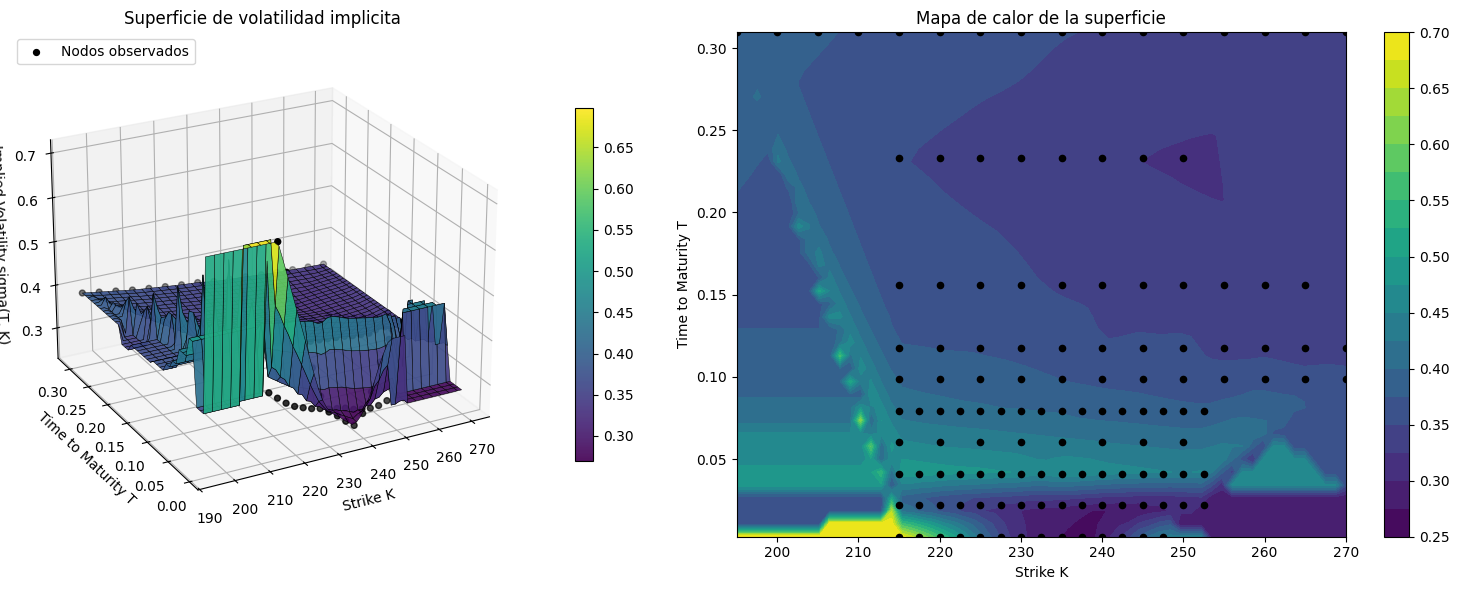

In [84]:
def to_plotly_colorscale(cmap):
    colorscale_map = {
        "viridis": "Viridis",
        "plasma": "Plasma",
        "inferno": "Inferno",
        "magma": "Magma",
        "cividis": "Cividis",
    }
    return colorscale_map.get(str(cmap).lower(), cmap)


def build_strike_surface_plot_grid(
    vol_model,
    strike_min=None,
    strike_max=None,
    maturity_min=None,
    maturity_max=None,
    num_strikes=60,
    num_maturities=40,
    q=0.0,
):
    quotes_iv = vol_model["quotes_iv"].copy()
    S_ref = float(quotes_iv["S"].iloc[0])
    r_ref = float(quotes_iv["r_cont"].iloc[0])
    q_ref = float(quotes_iv["q"].iloc[0]) if "q" in quotes_iv.columns else float(q)

    strike_min = float(quotes_iv["K"].min()) if strike_min is None else float(strike_min)
    strike_max = float(quotes_iv["K"].max()) if strike_max is None else float(strike_max)
    maturity_min = float(quotes_iv["T"].min()) if maturity_min is None else float(maturity_min)
    maturity_max = float(quotes_iv["T"].max()) if maturity_max is None else float(maturity_max)

    strike_grid = np.linspace(strike_min, strike_max, num_strikes)

    if vol_model["model_type"] == "smile":
        maturity = float(quotes_iv["T"].iloc[0])
        iv_curve = np.array([
            evaluate_vol_model(vol_model, S_ref, strike, maturity, r_ref, q=q_ref)
            for strike in strike_grid
        ])
        return {
            "model_type": "smile",
            "strike_grid": strike_grid,
            "maturity": maturity,
            "iv_curve": iv_curve,
            "quotes_iv": quotes_iv,
        }

    maturity_grid = np.linspace(maturity_min, maturity_max, num_maturities)
    strike_mesh, maturity_mesh = np.meshgrid(strike_grid, maturity_grid)
    evaluator = np.vectorize(
        lambda strike, maturity: evaluate_vol_model(vol_model, S_ref, strike, maturity, r_ref, q=q_ref),
        otypes=[float],
    )
    iv_mesh = evaluator(strike_mesh, maturity_mesh)

    return {
        "model_type": "surface",
        "strike_grid": strike_grid,
        "maturity_grid": maturity_grid,
        "strike_mesh": strike_mesh,
        "maturity_mesh": maturity_mesh,
        "iv_mesh": iv_mesh,
        "quotes_iv": quotes_iv,
    }


def plot_vol_model(vol_model, num_strikes=60, num_maturities=40, cmap="viridis", q=0.0):
    plot_data = build_strike_surface_plot_grid(
        vol_model,
        num_strikes=num_strikes,
        num_maturities=num_maturities,
        q=q,
    )

    quotes_iv = plot_data["quotes_iv"]

    if plot_data["model_type"] == "smile":
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(
            plot_data["strike_grid"],
            plot_data["iv_curve"],
            color="steelblue",
            linewidth=2,
            label="Smile interpolado",
        )
        ax.scatter(
            quotes_iv["K"],
            quotes_iv["iv"],
            color="black",
            s=35,
            label="IV observada",
            zorder=3,
        )
        ax.set_title("Smile de volatilidad implicita")
        ax.set_xlabel("Strike K")
        ax.set_ylabel("Volatilidad implicita")
        ax.grid(alpha=0.25)
        ax.legend()
        plt.tight_layout()
        return fig, ax

    fig = plt.figure(figsize=(16, 6))
    ax_surface = fig.add_subplot(1, 2, 1, projection="3d")
    surface = ax_surface.plot_surface(
        plot_data["strike_mesh"],
        plot_data["maturity_mesh"],
        plot_data["iv_mesh"],
        cmap=cmap,
        linewidth=0.35,
        edgecolor="black",
        antialiased=True,
        alpha=0.92,
    )
    ax_surface.scatter(
        quotes_iv["K"],
        quotes_iv["T"],
        quotes_iv["iv"],
        color="black",
        s=18,
        label="Nodos observados",
    )
    ax_surface.set_title("Superficie de volatilidad implicita")
    ax_surface.set_xlabel("Strike K")
    ax_surface.set_ylabel("Time to Maturity T")
    ax_surface.set_zlabel("Implied Volatility sigma(T, K)")
    ax_surface.view_init(elev=24, azim=-118)
    ax_surface.legend(loc="upper left")
    fig.colorbar(surface, ax=ax_surface, shrink=0.7, pad=0.08)

    ax_heatmap = fig.add_subplot(1, 2, 2)
    contour = ax_heatmap.contourf(
        plot_data["strike_mesh"],
        plot_data["maturity_mesh"],
        plot_data["iv_mesh"],
        levels=20,
        cmap=cmap,
    )
    ax_heatmap.scatter(quotes_iv["K"], quotes_iv["T"], color="black", s=20)
    ax_heatmap.set_title("Mapa de calor de la superficie")
    ax_heatmap.set_xlabel("Strike K")
    ax_heatmap.set_ylabel("Time to Maturity T")
    fig.colorbar(contour, ax=ax_heatmap)

    plt.tight_layout()
    return fig, (ax_surface, ax_heatmap)


def build_interactive_surface_figure(
    vol_model,
    num_strikes=60,
    num_maturities=40,
    cmap="viridis",
    q=0.0,
):
    plot_data = build_strike_surface_plot_grid(
        vol_model,
        num_strikes=num_strikes,
        num_maturities=num_maturities,
        q=q,
    )

    if plot_data["model_type"] != "surface":
        raise ValueError("La grafica interactiva solo esta disponible para una superficie con varios vencimientos.")

    quotes_iv = plot_data["quotes_iv"]
    colorscale = to_plotly_colorscale(cmap)
    fig = go.Figure()
    fig.add_trace(
        go.Surface(
            x=plot_data["strike_mesh"],
            y=plot_data["maturity_mesh"],
            z=plot_data["iv_mesh"],
            colorscale=colorscale,
            opacity=0.92,
            colorbar=dict(title="IV"),
            name="Superficie",
        )
    )
    fig.add_trace(
        go.Scatter3d(
            x=quotes_iv["K"],
            y=quotes_iv["T"],
            z=quotes_iv["iv"],
            mode="markers",
            marker=dict(size=3, color="black"),
            name="Nodos observados",
        )
    )
    fig.update_layout(
        title="Superficie de volatilidad implicita",
        scene=dict(
            xaxis_title="Strike K",
            yaxis_title="Time to Maturity T",
            zaxis_title="Implied Volatility sigma(T, K)",
            camera=dict(eye=dict(x=1.6, y=-1.7, z=1.0)),
        ),
        width=950,
        height=700,
        margin=dict(l=0, r=0, b=0, t=50),
    )
    return fig


if "amzn_surface_model" in globals():
    fig_amzn_surface, axes_amzn_surface = plot_vol_model(amzn_surface_model)

In [85]:
if "amzn_surface_model" in globals() and amzn_surface_model["model_type"] == "surface":
    amzn_surface_dynamic = build_interactive_surface_figure(amzn_surface_model)
    amzn_surface_dynamic

In [86]:
amzn_surface_dynamic

In [87]:
if {"df_bs", "df_K"}.issubset(globals()):
    sigma_surface_results = build_surface_sigma_tables(
        df_bs=df_bs,
        df_K=df_K,
        quotes_csv_path="AMZN_options_base_3m.csv",
        q=0.0,
        rate=float(df_bs["r_cont"].iloc[0]),
        use_otm_only=True,
    )

    tabla_sigma_superficie = sigma_surface_results["sigma_table"]
    tabla_sigma_superficie_pct = sigma_surface_results["sigma_table_pct"]
    tabla_sigma_superficie_fuente = sigma_surface_results["sigma_source_table"]
    detalle_sigma_superficie = sigma_surface_results["sigma_details"]

tabla_sigma_superficie_pct

,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
sigma implied 140,38.97%,39.83%,44.47%,40.93%,44.29%,44.34%,44.09%,42.79%,46.01%,45.75%,47.90%,48.60%,50.82%
sigma implied 170,38.97%,39.83%,44.47%,40.93%,42.15%,36.27%,44.09%,42.79%,46.01%,45.75%,46.53%,48.60%,50.82%
sigma implied 195,38.97%,39.83%,48.65%,32.92%,34.15%,34.42%,36.03%,34.68%,40.85%,36.48%,37.87%,40.80%,39.86%
sigma implied 212.5,36.23%,41.25%,43.29%,31.51%,32.28%,31.93%,32.39%,31.71%,33.94%,30.54%,31.43%,31.32%,33.59%
sigma implied 227.5,34.50%,37.01%,43.67%,31.44%,45.65%,33.25%,32.35%,30.22%,30.39%,26.56%,29.22%,26.92%,31.35%
sigma implied 235,33.62%,36.61%,40.70%,33.65%,32.38%,31.28%,33.97%,31.73%,29.14%,28.50%,28.22%,40.63%,30.30%
sigma implied 252.5,32.49%,35.40%,41.82%,35.61%,37.21%,36.46%,37.09%,30.11%,29.15%,27.34%,35.04%,25.50%,36.32%
sigma implied 270,33.85%,35.29%,42.61%,35.61%,37.21%,36.46%,37.09%,36.60%,34.95%,33.45%,35.04%,34.35%,36.32%
sigma implied 280,33.03%,36.12%,40.50%,35.61%,37.21%,36.46%,37.09%,36.60%,34.95%,33.45%,35.04%,34.35%,36.32%
sigma implied 290,33.03%,36.36%,40.50%,35.61%,37.21%,36.46%,37.09%,36.60%,34.95%,33.45%,35.04%,34.35%,36.32%


# BLACK-SCHOLES MODEL


In [88]:
df_iv_raw = pd.read_excel("AMZN_options_base_3m.csv.xlsx")

# Clean and filter
df_iv_raw["Strike"]             = pd.to_numeric(df_iv_raw["Strike"], errors="coerce")
df_iv_raw["Implied Volatility"] = pd.to_numeric(df_iv_raw["Implied Volatility"], errors="coerce")
df_iv_raw["Data"]               = pd.to_datetime(df_iv_raw["Data"])

# Only calls, just the 11 strikes of the portfolio
strikes_eira = df_K["K"].tolist()

df_iv_clean = df_iv_raw[
    (df_iv_raw["Type"] == "Calls") &
    (df_iv_raw["Strike"].isin(strikes_eira)) &
    (df_iv_raw["Data"] != pd.Timestamp("2026-04-09"))
].copy()

# Pivot: rows = strikes, columns = dates
tabla_sigma_superficie = (
    df_iv_clean
    .pivot_table(index="Strike", columns="Data", values="Implied Volatility", aggfunc="first")
    .sort_index()
)
tabla_sigma_superficie.columns = [c.strftime("%Y-%m-%d") for c in tabla_sigma_superficie.columns]

print("tabla_sigma_superficie built ✓")
print(f"  Strikes: {tabla_sigma_superficie.shape[0]}, Dates: {tabla_sigma_superficie.shape[1]}")
tabla_sigma_superficie.round(4)

tabla_sigma_superficie built ✓
  Strikes: 11, Dates: 13


,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
Strike,,,,,,,,,,,,,
140.0,0.7688,0.7061,0.6899,0.6267,0.5856,0.6285,0.6638,2.0000,6.0107,NaN,2.6875,3.9316,3.4531
170.0,0.5922,0.5620,0.5516,0.5032,0.4913,0.4877,0.5450,0.9063,2.8809,1.6758,1.7969,2.4512,2.4844
195.0,0.5073,0.4981,0.5194,0.4149,0.4243,0.4210,0.4553,0.6372,1.0234,1.0356,0.7578,0.7207,0.8389
212.5,0.4430,NaN,NaN,NaN,NaN,NaN,NaN,0.2402,0.5420,0.3057,0.3672,0.3467,0.3848
227.5,0.3889,NaN,NaN,NaN,NaN,NaN,NaN,0.5000,0.3867,0.3672,0.5938,0.4336,0.6250
235.0,0.3714,0.4128,0.4511,0.3731,0.3878,0.3778,0.3892,0.5625,0.5313,0.4844,0.7813,0.5469,0.8125
252.5,0.3508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
270.0,0.3511,0.3791,0.4109,0.3785,0.4002,0.3829,0.3865,1.1250,1.4844,1.3359,1.5625,1.0625,1.6250
280.0,0.3533,0.3749,0.4066,0.3848,0.4072,0.3864,0.3908,1.4688,1.6563,1.5117,1.7500,1.3906,2.5000


In [89]:
# Build tabla_mercado from the same dataset
df_market = df_iv_clean.copy()
df_market["Bid"]        = pd.to_numeric(df_market["Bid"], errors="coerce")
df_market["Ask"]        = pd.to_numeric(df_market["Ask"], errors="coerce")
df_market["Last Price"] = pd.to_numeric(df_market["Last Price"], errors="coerce")

df_market["Mid"] = (df_market["Bid"] + df_market["Ask"]) / 2
df_market["Market Price"] = df_market["Mid"].where(
    df_market["Mid"].notna() & (df_market["Mid"] > 0),
    df_market["Last Price"]
)

tabla_mercado = (
    df_market
    .pivot_table(index="Strike", columns="Data", values="Market Price", aggfunc="first")
    .sort_index()
)
tabla_mercado.columns = [pd.to_datetime(c).strftime("%Y-%m-%d") for c in tabla_mercado.columns]
print("tabla_mercado built ✓")

tabla_mercado built ✓


In [90]:
# Black-Scholes Parameters
# ────────────────────────────────────────────────────────────

# Fixed volatility: average of the 13 weekly historical volatilities
sigma_fija = float(df_bs["sigma"].mean())

# Implied volatility: extracted from market by strike and date
# (already built in the previous cell as tabla_sigma_superficie)
# Verify it is available
if "tabla_sigma_superficie" not in globals():
    raise RuntimeError(
        "tabla_sigma_superficie is not defined. "
        "Run the cell that builds the IV surface first."
    )

print("=" * 55)
print("BLACK-SCHOLES — Model Parameters")
print("=" * 55)
print(f"  Fixed σ   (historical, constant) : {sigma_fija:.4f}  ({sigma_fija*100:.2f}%)")
print(f"  r         (risk-free rate)        : {df_bs['r_cont'].iloc[0]:.4f}  ({df_bs['r_cont'].iloc[0]*100:.2f}%)")
print(f"  S₀        (initial spot price)    : {df_bs['S'].iloc[0]:.2f}")
print(f"  T₀        (time to maturity, yrs) : {df_bs['T'].iloc[0]:.3f}  ({int(df_bs['T'].iloc[0]*365)} days)")
print(f"  Strikes   (EIRA contracts)        : {df_K['K'].tolist()}")
print()
print("  Implied σ: extracted per (K, t) from Base_09-04_.xlsx")
print("             using Brent's method on OTM prices")

BLACK-SCHOLES — Model Parameters
  Fixed σ   (historical, constant) : 0.2916  (29.16%)
  r         (risk-free rate)        : 0.0417  (4.17%)
  S₀        (initial spot price)    : 234.34
  T₀        (time to maturity, yrs) : 0.211  (77 days)
  Strikes   (EIRA contracts)        : [140.0, 170.0, 195.0, 212.5, 227.5, 235.0, 252.5, 270.0, 280.0, 290.0, 300.0]

  Implied σ: extracted per (K, t) from Base_09-04_.xlsx
             using Brent's method on OTM prices


## Scenario A — BS Prices with FIXED σ
### A single sigma for all strikes and all dates

In [91]:
# Create a copy of df_bs with constant sigma for all rows
df_bs_fija = df_bs.copy()
df_bs_fija["sigma"] = sigma_fija   # overwrite the weekly sigma with the fixed one

# call_premium_table handles the calculation; we just pass df with fixed sigma
tabla_bs_fija = call_premium_table(df_bs_fija, df_K)

# Rename columns to yyyy-mm-dd format for consistency with Merton
tabla_bs_fija.columns = [
    pd.to_datetime(c).strftime("%Y-%m-%d") for c in tabla_bs_fija.columns
]

print("Black-Scholes — Prices with fixed σ =", round(sigma_fija * 100, 2), "%")
print("(rows = strikes, columns = observation dates)\n")
tabla_bs_fija

Black-Scholes — Prices with fixed σ = 29.16 %
(rows = strikes, columns = observation dates)



,2026-01-22,2026-01-29,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-02-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26,2026-03-05
K,,,,,,,,,,,,,
140.0,95.57,102.85,67.89,61.97,65.22,69.26,68.59,83.70,73.87,69.52,71.95,67.76,79.50
170.0,65.89,73.10,38.44,32.61,35.68,39.55,38.86,54.00,43.95,39.60,42.00,37.81,49.63
195.0,42.01,48.74,17.37,12.72,14.76,17.39,16.70,30.64,19.73,15.76,17.46,13.60,25.52
212.5,27.30,33.02,7.76,4.81,5.83,7.14,6.61,17.37,7.02,4.60,4.78,2.80,11.94
227.5,17.20,21.60,3.26,1.68,2.11,2.61,2.31,9.33,1.83,0.93,0.74,0.30,4.77
235.0,13.19,16.88,1.99,0.92,1.17,1.46,1.25,6.52,0.79,0.34,0.22,0.07,2.73
252.5,6.50,8.64,0.54,0.19,0.25,0.30,0.24,2.50,0.07,0.02,0.01,0.00,0.57
270.0,2.84,3.88,0.12,0.03,0.04,0.05,0.03,0.81,0.00,0.00,0.00,0.00,0.09
280.0,1.68,2.33,0.05,0.01,0.01,0.02,0.01,0.40,0.00,0.00,0.00,0.00,0.03


## Scenario B — BS Prices with IMPLIED σ per (K, t)
### Each strike on each date uses its own IV extracted from the market

In [92]:
def bs_call_table_iv(df_bs, df_K, tabla_iv, time_col="fecha_obs"):
    """
    Computes Black-Scholes prices using the implied volatility
    corresponding to each (strike K, date t) pair.

    Parameters
    ----------
    df_bs     : DataFrame with columns fecha_obs, S, T, r_cont
    df_K      : DataFrame with column K (the 11 strikes)
    tabla_iv  : DataFrame with index = strikes and columns = dates (yyyy-mm-dd)
                Same format as tabla_sigma_superficie from the prior project.
    """
    records = []

    for _, row in df_bs.iterrows():
        fecha_label = pd.to_datetime(row[time_col]).strftime("%Y-%m-%d")
        S = row["S"]
        T = row["T"]
        r = row["r_cont"]

        for _, krow in df_K.iterrows():
            K = krow["K"]

            # Look up IV corresponding to this (K, date) pair
            try:
                iv = float(tabla_iv.loc[K, fecha_label])
            except KeyError:
                iv = float("nan")

            # If no IV available, use fixed sigma as fallback
            if pd.isna(iv) or iv <= 0:
                iv = sigma_fija

            price = bs_call_price(S=S, K=K, r=r, sigma=iv, T=T)
            records.append({"K": K, "fecha": fecha_label, "call_price": price})

    tabla = (
        pd.DataFrame(records)
        .pivot(index="K", columns="fecha", values="call_price")
        .sort_index()
        .round(4)
    )
    return tabla


# tabla_sigma_superficie has the correct format: index=K, columns=dates
tabla_bs_iv = bs_call_table_iv(df_bs, df_K, tabla_sigma_superficie)

print("Black-Scholes — Prices with implied σ per (K, t)")
print("(rows = strikes, columns = observation dates)\n")
tabla_bs_iv

Black-Scholes — Prices with implied σ per (K, t)
(rows = strikes, columns = observation dates)



fecha,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
K,,,,,,,,,,,,,
140.0,97.4820,103.6663,84.7487,68.8865,62.6646,65.9797,69.9010,87.7744,158.3750,73.8673,86.9528,97.0875,86.9182
170.0,68.7678,74.6651,56.3548,41.1195,35.2518,37.8223,41.8280,47.3283,94.2701,58.4555,55.9032,61.9351,57.9931
195.0,46.7145,52.0485,36.0616,20.8709,16.4737,18.2080,21.2724,25.0887,40.2005,31.9350,23.1446,22.2380,20.5162
212.5,32.2907,33.0167,17.3680,7.7639,4.8063,5.8324,7.1368,5.1785,18.3425,7.3184,6.1077,5.7229,4.2354
227.5,21.1567,21.6047,9.3330,3.2578,1.6774,2.1050,2.6146,7.2352,7.2499,3.0949,5.5078,2.3136,3.5221
235.0,16.5914,21.7529,12.2520,3.8593,2.4623,2.6772,3.3166,6.8874,8.5006,3.4568,6.9466,2.3559,4.3851
252.5,8.8641,8.6422,2.4951,0.5419,0.1918,0.2500,0.3032,0.2397,0.5744,0.0706,0.0204,0.0061,0.0010
270.0,4.6462,6.9145,2.9445,0.6212,0.3578,0.3224,0.3670,13.3641,23.6415,11.5449,13.2507,3.3596,8.5439
280.0,3.1701,4.7060,1.8648,0.3787,0.2126,0.1722,0.1948,20.2841,25.7856,12.9334,14.7162,5.8151,19.1310


### Scenario A vs B Comparison: price difference BS fixed vs implied

In [93]:
diff_fija_vs_iv = (tabla_bs_iv - tabla_bs_fija).round(4)

print("BS(σ_IV) − BS(σ_fixed)  [absolute difference in $]")
print("Positive = IV produces a higher premium than fixed σ\n")
diff_fija_vs_iv

BS(σ_IV) − BS(σ_fixed)  [absolute difference in $]
Positive = IV produces a higher premium than fixed σ



fecha,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
K,,,,,,,,,,,,,
140.0,1.9120,0.8163,1.0487,0.9965,0.6946,0.7597,0.6410,19.1844,78.8750,-0.0027,17.4328,25.1375,19.1582
170.0,2.8778,1.5651,2.3548,2.6795,2.6418,2.1423,2.2780,8.4683,44.6401,14.5055,16.3032,19.9351,20.1831
195.0,4.7045,3.3085,5.4216,3.5009,3.7537,3.4480,3.8824,8.3887,14.6805,12.2050,7.3846,4.7780,6.9162
212.5,4.9907,-0.0033,-0.0020,0.0039,-0.0037,0.0024,-0.0032,-1.4315,6.4025,0.2984,1.5077,0.9429,1.4354
227.5,3.9567,0.0047,0.0030,-0.0022,-0.0026,-0.0050,0.0046,4.9252,2.4799,1.2649,4.5778,1.5736,3.2221
235.0,3.4014,4.8729,5.7320,1.8693,1.5423,1.5072,1.8566,5.6374,5.7706,2.6668,6.6066,2.1359,4.3151
252.5,2.3641,0.0022,-0.0049,0.0019,0.0018,0.0000,0.0032,-0.0003,0.0044,0.0006,0.0004,-0.0039,0.0010
270.0,1.8062,3.0345,2.1345,0.5012,0.3278,0.2824,0.3170,13.3341,23.5515,11.5449,13.2507,3.3596,8.5439
280.0,1.4901,2.3760,1.4648,0.3287,0.2026,0.1622,0.1748,20.2741,25.7556,12.9334,14.7162,5.8151,19.1310


### Comparison BS vs Mercado — Scenario A (σ fixed)

In [94]:
# Align indices with tabla_mercado
tabla_mercado_idx = tabla_mercado.reindex(
    index=tabla_bs_fija.index,
    columns=tabla_bs_fija.columns
)

diff_fija_mercado = (tabla_bs_fija - tabla_mercado_idx).round(4)

# Error metrics
errors_fija   = diff_fija_mercado.stack().dropna()
abs_err_fija  = errors_fija.abs()
pct_fija      = ((diff_fija_mercado / tabla_mercado_idx.abs()) * 100).stack().dropna()

mae_fija   = abs_err_fija.mean()
rmse_fija  = (errors_fija**2).mean() ** 0.5
mape_fija  = pct_fija.abs().mean()
bias_fija  = errors_fija.mean()

print("Black-Scholes (fixed σ) — Pricing Error vs Market")
print("-" * 52)
print(f"  MAE   : {mae_fija:.4f}")
print(f"  RMSE  : {rmse_fija:.4f}")
print(f"  MAPE  : {mape_fija:.2f}%")
print(f"  Bias  : {bias_fija:+.4f}  (+ overpricing, − underpricing)")
print(f"  N obs : {len(errors_fija)}")

Black-Scholes (fixed σ) — Pricing Error vs Market
----------------------------------------------------
  MAE   : 2.5115
  RMSE  : 4.5914
  MAPE  : 1565.87%
  Bias  : -1.4585  (+ overpricing, − underpricing)
  N obs : 116


### Comparison BS vs Mercado — Scenario B (σ implied)

In [95]:
tabla_mercado_iv_idx = tabla_mercado.reindex(
    index=tabla_bs_iv.index,
    columns=tabla_bs_iv.columns
)

diff_iv_mercado = (tabla_bs_iv - tabla_mercado_iv_idx).round(4)

errors_iv  = diff_iv_mercado.stack().dropna()
abs_err_iv = errors_iv.abs()
pct_iv     = ((diff_iv_mercado / tabla_mercado_iv_idx.abs()) * 100).stack().dropna()

mae_iv   = abs_err_iv.mean()
rmse_iv  = (errors_iv**2).mean() ** 0.5
mape_iv  = pct_iv.abs().mean()
bias_iv  = errors_iv.mean()

print("Black-Scholes (implied σ) — Pricing Error vs Market")
print("-" * 52)
print(f"  MAE   : {mae_iv:.4f}")
print(f"  RMSE  : {rmse_iv:.4f}")
print(f"  MAPE  : {mape_iv:.2f}%")
print(f"  Bias  : {bias_iv:+.4f}  (+ overpricing, − underpricing)")
print(f"  N obs : {len(errors_iv)}")

Black-Scholes (implied σ) — Pricing Error vs Market
----------------------------------------------------
  MAE   : 8.2400
  RMSE  : 13.4868
  MAPE  : 38155.97%
  Bias  : +5.9464  (+ overpricing, − underpricing)
  N obs : 116


## Summary table of prices at the initial date (January 22, 2026)
### Market | BS σ-fixed | BS σ-implied  — first column of each table only

In [96]:
fecha_inicio = tabla_bs_fija.columns[0]   # "2026-01-22"

resumen_inicial = pd.DataFrame({
    "Strike (K)"      : df_K["K"].values,
    "Moneyness"       : ["Deep ITM","Deep ITM","ITM","ITM","ITM",
                         "ATM","OTM","OTM","Deep OTM","Deep OTM","Deep OTM"],
    "Market"          : tabla_mercado_idx[fecha_inicio].values,
    "BS σ-fixed"      : tabla_bs_fija[fecha_inicio].values,
    "BS σ-implied"    : tabla_bs_iv[fecha_inicio].values,
}).set_index("Strike (K)")

print(f"Prices on {fecha_inicio} — Market vs Black-Scholes (both scenarios)\n")
resumen_inicial.round(2)

Prices on 2026-01-22 — Market vs Black-Scholes (both scenarios)



,Moneyness,Market,BS σ-fixed,BS σ-implied
Strike (K),,,,
140.0,Deep ITM,116.12,95.57,97.48
170.0,Deep ITM,86.82,65.89,68.77
195.0,ITM,63.78,42.01,46.71
212.5,ITM,42.40,27.30,32.29
227.5,ITM,22.08,17.20,21.16
235.0,ATM,14.75,13.19,16.59
252.5,OTM,4.85,6.50,8.86
270.0,OTM,1.48,2.84,4.65
280.0,Deep OTM,1.06,1.68,3.17


# Merton Jump–Diffusion Model

## Theory

The Black–Scholes model assumes that the asset price follows a continuous geometric Brownian motion. However, in practice prices exhibit sudden jumps triggered by events such as earnings releases, regulatory changes, or macroeconomic shocks. The **Merton (1976)** model extends Black–Scholes by incorporating a compound Poisson jump process:

$$
dS_t = (\mu - \lambda\bar{k})\,S_t\,dt + \sigma S_t\,dW_t + S_{t^-}(J-1)\,dN_t
$$

where the components are:

| Symbol | Description |
|--------|-------------|
| $\sigma$ | Diffusive (continuous) volatility |
| $W_t$ | Standard Brownian motion |
| $N_t$ | Poisson process with intensity $\lambda$ |
| $J = e^Y$, $\;Y\sim\mathcal{N}(\mu_J,\sigma_J^2)$ | Jump size (log-normal) |
| $\bar{k} = \mathbb{E}[J-1] = e^{\mu_J + \frac{1}{2}\sigma_J^2}-1$ | Mean net jump size |

The term $\lambda\bar{k}$ adjusts the drift to maintain risk neutrality: it offsets the additional expected return introduced by the jump component.

### Log-price dynamics

Applying the generalized Itô lemma, the log-price under the risk-neutral measure $\mathbb{Q}$ satisfies:

$$
\ln S_T = \ln S_0 + \left(r - \lambda\bar{k} - \frac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}\,Z + \sum_{i=1}^{N_T} Y_i
$$

where $Z \sim \mathcal{N}(0,1)$ is independent of $N_T$ and of the $Y_i \sim \mathcal{N}(\mu_J, \sigma_J^2)$.

Given $N_T = n$, the jump sum $\sum_{i=1}^{n} Y_i \sim \mathcal{N}(n\mu_J,\; n\sigma_J^2)$, so the conditional log-price is normal. This allows the option price to be written as an **infinite mixture of Black–Scholes formulas** weighted by Poisson probabilities:

$$
C^{\text{Merton}}(S_0, K, T) = \sum_{n=0}^{\infty} \frac{e^{-\lambda' T}(\lambda' T)^n}{n!}\; C^{\text{BS}}\!\left(S_0,\, K,\, r_n,\, \sigma_n,\, T\right)
$$

with the parameters adjusted by number of jumps $n$:

$$
\lambda' = \lambda(1+\bar{k}), \qquad
\sigma_n^2 = \sigma^2 + \frac{n\,\sigma_J^2}{T}, \qquad
r_n = r - \lambda\bar{k} + \frac{n\!\left(\mu_J + \tfrac{1}{2}\sigma_J^2\right)}{T}
$$

In practice the series is truncated at $n_{\max}$ terms (typically 50), since the Poisson weights $e^{-\lambda' T}(\lambda' T)^n/n!$ decay exponentially.

### Model parameters and literature reference values

The four Merton parameters have a direct economic interpretation:

| Parameter | Description | Value used |
|-----------|-------------|------------|
| $\sigma$ | Diffusive volatility | Average of $\sigma$ in `df_bs` |
| $\lambda$ | Jump intensity (jumps/year) | $1.0$ |
| $\mu_J$ | Mean log-jump | $-0.05$ (slightly negative jumps on average) |
| $\sigma_J$ | Std. deviation of log-jump | $0.15$ |

The values $\lambda=1$, $\mu_J=-0.05$ and $\sigma_J=0.15$ are consistent with estimates reported in Merton (1976) and Cont & Tankov (2004) for large-cap equity stocks: on average one jump per year, of moderate magnitude and with a negative bias.

### Monte Carlo valuation

The semi-analytic formula exists, but it is also possible — and methodologically instructive — to price via **Monte Carlo simulation** of the terminal price $S_T$.

For each path $i = 1,\ldots,M$:

1. Simulate $N_T^{(i)} \sim \text{Poisson}(\lambda T)$.
2. Simulate $Z^{(i)} \sim \mathcal{N}(0,1)$ (diffusive component).
3. Simulate the jump sum: $\displaystyle\sum_{j=1}^{N_T^{(i)}} Y_j^{(i)} \sim \mathcal{N}\!\left(N_T^{(i)}\mu_J,\; N_T^{(i)}\sigma_J^2\right)$.
4. Compute the terminal log-price:

$$
\ln S_T^{(i)} = \ln S_0 + \left(r - \lambda\bar{k} - \tfrac{1}{2}\sigma^2\right)T + \sigma\sqrt{T}\,Z^{(i)} + N_T^{(i)}\mu_J + \sqrt{N_T^{(i)}}\,\sigma_J\,\tilde{Z}^{(i)}
$$

The call option price is estimated as the discounted average of the payoffs:

$$
\hat{C} = e^{-rT}\,\frac{1}{M}\sum_{i=1}^{M}\max\!\left(S_T^{(i)} - K,\; 0\right)
$$

with standard error $\text{SE} = e^{-rT}\,\hat{\sigma}_{\text{payoff}} / \sqrt{M}$.

In [97]:
df_iv_raw = pd.read_excel("AMZN_options_base_3m.csv.xlsx")

# Clean and filter
df_iv_raw["Strike"]             = pd.to_numeric(df_iv_raw["Strike"], errors="coerce")
df_iv_raw["Implied Volatility"] = pd.to_numeric(df_iv_raw["Implied Volatility"], errors="coerce")
df_iv_raw["Data"]               = pd.to_datetime(df_iv_raw["Data"])

# Only calls, just the 11 strikes of the portfolio
strikes_eira = df_K["K"].tolist()

df_iv_clean = df_iv_raw[
    (df_iv_raw["Type"] == "Calls") &
    (df_iv_raw["Strike"].isin(strikes_eira)) &
    (df_iv_raw["Data"] != pd.Timestamp("2026-04-09"))
].copy()

# Pivot: rows = strikes, columns = dates
tabla_sigma_superficie = (
    df_iv_clean
    .pivot_table(index="Strike", columns="Data", values="Implied Volatility", aggfunc="first")
    .sort_index()
)
tabla_sigma_superficie.columns = [c.strftime("%Y-%m-%d") for c in tabla_sigma_superficie.columns]

print("tabla_sigma_superficie built ✓")
print(f"  Strikes: {tabla_sigma_superficie.shape[0]}, Dates: {tabla_sigma_superficie.shape[1]}")
tabla_sigma_superficie.round(4)

tabla_sigma_superficie built ✓
  Strikes: 11, Dates: 13


,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
Strike,,,,,,,,,,,,,
140.0,0.7688,0.7061,0.6899,0.6267,0.5856,0.6285,0.6638,2.0000,6.0107,NaN,2.6875,3.9316,3.4531
170.0,0.5922,0.5620,0.5516,0.5032,0.4913,0.4877,0.5450,0.9063,2.8809,1.6758,1.7969,2.4512,2.4844
195.0,0.5073,0.4981,0.5194,0.4149,0.4243,0.4210,0.4553,0.6372,1.0234,1.0356,0.7578,0.7207,0.8389
212.5,0.4430,NaN,NaN,NaN,NaN,NaN,NaN,0.2402,0.5420,0.3057,0.3672,0.3467,0.3848
227.5,0.3889,NaN,NaN,NaN,NaN,NaN,NaN,0.5000,0.3867,0.3672,0.5938,0.4336,0.6250
235.0,0.3714,0.4128,0.4511,0.3731,0.3878,0.3778,0.3892,0.5625,0.5313,0.4844,0.7813,0.5469,0.8125
252.5,0.3508,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
270.0,0.3511,0.3791,0.4109,0.3785,0.4002,0.3829,0.3865,1.1250,1.4844,1.3359,1.5625,1.0625,1.6250
280.0,0.3533,0.3749,0.4066,0.3848,0.4072,0.3864,0.3908,1.4688,1.6563,1.5117,1.7500,1.3906,2.5000


## Code

In [98]:
# Diffusive volatility: average of the historical sigmas from the project
fixed_vol = float(df_bs["sigma"].mean())

# Merton parameters — reference values from the literature
# (Merton 1976; Cont & Tankov 2004)
merton_params = {
    "sigma"   : fixed_vol,  # diffusive volatility, same as BS
    "lambda_j": 1.0,        # jump intensity: ~1 jump/year
    "mu_j"    : -0.05,      # mean log-jump (slightly negative jumps on average)
    "sigma_j" : 0.15,       # std deviation of log-jump
}
print(f"Fixed volatility used : {round(fixed_vol, 4)}")
print(f"Merton parameters     : {merton_params}")

Fixed volatility used : 0.2916
Merton parameters     : {'sigma': 0.2916384615384615, 'lambda_j': 1.0, 'mu_j': -0.05, 'sigma_j': 0.15}


In [99]:
def simulate_merton_terminal(
    S0, T, r, sigma, lambda_j, mu_j, sigma_j,
    n_paths=50_000, seed=42
):
    """
    Simulates terminal prices S_T under the Merton jump-diffusion model.

    Jump component:
        J = exp(Y),  Y ~ Normal(mu_j, sigma_j^2)
        N_T ~ Poisson(lambda_j * T)

    Risk-neutral drift adjustment:
        k = E[J - 1] = exp(mu_j + 0.5*sigma_j^2) - 1
    """
    rng = np.random.default_rng(seed)

    # Componente difusiva
    z = rng.standard_normal(n_paths)

    # Número de saltos por trayectoria
    n_jumps = rng.poisson(lambda_j * T, n_paths)

    # Suma de log-saltos: N(n*mu_j, n*sigma_j^2)
    jump_sum = (
        n_jumps * mu_j
        + np.sqrt(n_jumps) * sigma_j * rng.standard_normal(n_paths)
    )

    # Ajuste de compensación (deriva neutral al riesgo)
    k = np.exp(mu_j + 0.5 * sigma_j**2) - 1

    # Log-precio terminal
    log_ST = (
        np.log(S0)
        + (r - lambda_j * k - 0.5 * sigma**2) * T
        + sigma * np.sqrt(T) * z
        + jump_sum
    )

    return np.exp(log_ST)

In [100]:
def mc_call_price_from_terminal(ST, K, T, r):
    """
    European call price via Monte Carlo from terminal prices S_T.

    Returns:
        price : estimated price (mean of discounted payoffs)
        se    : standard error of the estimate
    """
    discounted_payoff = np.exp(-r * T) * np.maximum(ST - K, 0)
    price = discounted_payoff.mean()
    se    = discounted_payoff.std(ddof=1) / np.sqrt(len(discounted_payoff))
    return price, se

In [101]:
def merton_call_price_table(df_bs, df_K, params, n_paths=50_000, seed=42, time_col="fecha_obs"):
    """
    Table of Merton call prices (MC) for each date × strike combination.
    Same format as call_premium_table from Black-Scholes.
    """
    sigma    = params["sigma"]
    lambda_j = params["lambda_j"]
    mu_j     = params["mu_j"]
    sigma_j  = params["sigma_j"]

    records = []
    for _, row in df_bs.iterrows():
        S0    = row["S"]
        T     = row["T"]
        r     = row["r_cont"]
        fecha = pd.to_datetime(row[time_col]).strftime("%Y-%m-%d")

        ST = simulate_merton_terminal(
            S0=S0, T=T, r=r,
            sigma=sigma, lambda_j=lambda_j, mu_j=mu_j, sigma_j=sigma_j,
            n_paths=n_paths, seed=seed,
        )

        for _, krow in df_K.iterrows():
            K = krow["K"]
            price, se = mc_call_price_from_terminal(ST, K, T, r)
            records.append({"fecha": fecha, "K": K, "merton_price": price, "se": se})

    df_long = pd.DataFrame(records)
    tabla = (
        df_long
        .pivot(index="K", columns="fecha", values="merton_price")
        .sort_index()
        .round(2)
    )
    return tabla

### Observed market prices — AMZN_options_base_3m.csv

Before computing Merton prices, the actual market prices are loaded for the same strikes and dates used in the project. The **mid-price** `(Bid + Ask) / 2` is used when available; otherwise, the `Last Price` is used as a fallback.

### Merton Price Table (Monte Carlo)

$M = 50{,}000$ paths are simulated for each observation date using the parameters in `merton_params`. The same terminal distribution $S_T$ is used for all strikes on that date.

In [102]:
tabla_merton = merton_call_price_table(df_bs, df_K, merton_params)
tabla_merton

fecha,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
K,,,,,,,,,,,,,
140.0,95.71,102.96,83.67,67.95,62.04,65.28,69.28,68.60,79.54,73.89,69.51,71.94,67.76
170.0,66.27,73.37,54.25,38.93,33.13,36.13,39.88,39.18,49.82,44.09,39.72,42.07,37.90
195.0,42.89,49.43,31.42,18.34,13.62,15.64,18.18,17.47,26.12,20.20,16.20,17.78,13.92
212.5,28.56,34.09,18.41,8.75,5.62,6.67,7.96,7.40,12.72,7.58,5.06,5.14,3.12
227.5,18.59,22.91,10.39,4.07,2.26,2.73,3.27,2.91,5.48,2.27,1.24,0.98,0.48
235.0,14.59,18.24,7.51,2.67,1.38,1.68,1.98,1.73,3.35,1.12,0.56,0.38,0.19
252.5,7.76,9.96,3.23,0.94,0.42,0.51,0.58,0.48,0.92,0.22,0.11,0.07,0.05
270.0,3.79,4.96,1.28,0.33,0.14,0.16,0.18,0.15,0.26,0.07,0.04,0.03,0.02
280.0,2.43,3.21,0.74,0.19,0.08,0.09,0.10,0.09,0.14,0.04,0.02,0.02,0.01


### Merton vs Black–Scholes Comparison

The table shows $C^{\text{Merton}} - C^{\text{BS}}$ (absolute difference). Positive values indicate that Merton assigns an additional premium for jump risk.

In [103]:
# BS prices in the same column convention
tabla_bs_raw = call_premium_table(df_bs, df_K)
tabla_bs_fmt = tabla_bs_raw.copy()
tabla_bs_fmt.columns = [
    pd.to_datetime(c).strftime("%Y-%m-%d") for c in tabla_bs_fmt.columns
]

diff_bs = (tabla_merton - tabla_bs_fmt).round(4)
diff_bs

fecha,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
K,,,,,,,,,,,,,
140.0,0.14,0.11,-0.03,0.06,0.07,0.06,0.02,0.01,0.04,0.02,-0.01,-0.01,0.00
170.0,0.35,0.26,0.28,0.42,0.54,0.48,0.33,0.33,0.19,0.14,0.12,0.07,0.09
195.0,0.69,0.63,1.06,0.68,0.96,1.03,0.82,0.86,0.59,0.50,0.48,0.30,0.30
212.5,0.87,0.91,1.59,0.64,0.88,1.01,0.86,0.92,0.75,0.62,0.52,0.32,0.28
227.5,0.87,1.04,1.68,0.54,0.62,0.74,0.69,0.69,0.67,0.49,0.34,0.22,0.17
235.0,0.85,1.07,1.58,0.46,0.49,0.59,0.55,0.55,0.59,0.36,0.24,0.15,0.12
252.5,0.75,1.01,1.13,0.30,0.24,0.29,0.29,0.26,0.33,0.15,0.09,0.06,0.05
270.0,0.58,0.84,0.67,0.17,0.11,0.12,0.13,0.12,0.17,0.07,0.04,0.03,0.02
280.0,0.47,0.70,0.46,0.12,0.07,0.08,0.09,0.08,0.11,0.04,0.02,0.02,0.01


In [104]:
# Diferencia relativa Merton vs BS (%)
diff_bs_pct = ((tabla_merton - tabla_bs_fmt) / tabla_bs_fmt.abs() * 100).round(2)
diff_bs_pct

fecha,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
K,,,,,,,,,,,,,
140.0,0.15,0.11,-0.04,0.09,0.11,0.09,0.03,0.01,0.05,0.03,-0.01,-0.01,0.00
170.0,0.53,0.36,0.52,1.09,1.66,1.35,0.83,0.85,0.38,0.32,0.30,0.17,0.24
195.0,1.64,1.29,3.49,3.85,7.58,7.05,4.72,5.18,2.31,2.54,3.05,1.72,2.20
212.5,3.14,2.74,9.45,7.89,18.57,17.84,12.11,14.20,6.27,8.91,11.45,6.64,9.86
227.5,4.91,4.76,19.29,15.30,37.80,37.19,26.74,31.08,13.93,27.53,37.78,28.95,54.84
235.0,6.19,6.23,26.64,20.81,55.06,54.13,38.46,46.61,21.38,47.37,75.00,65.22,171.43
252.5,10.70,11.28,53.81,46.87,133.33,131.82,100.00,118.18,55.93,214.29,450.00,600.00,inf
270.0,18.07,20.39,109.84,106.25,366.67,300.00,260.00,400.00,188.89,inf,inf,inf,inf
280.0,23.98,27.89,164.29,171.43,700.00,800.00,900.00,800.00,366.67,inf,inf,inf,inf


### Merton vs Market Comparison (AMZN_options_base_3m.csv)

The table shows $C^{\text{Merton}} - C^{\text{Market}}$ for each strike and date. This is the key model quality metric: a small error indicates that the Merton parameters capture the observed price well. `NaN` cells correspond to strikes/dates with no quote available in the dataset.

In [105]:
# Align indices: tabla_merton has float index, tabla_mercado may differ
tabla_merton_idx  = tabla_merton.copy()
tabla_mercado_idx = tabla_mercado.reindex(
    index=tabla_merton_idx.index,
    columns=tabla_merton_idx.columns
)

diff_market = (tabla_merton_idx - tabla_mercado_idx).round(4)
diff_market

fecha,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
K,,,,,,,,,,,,,
140.0,-20.415,-1.115,-1.930,-1.850,-1.435,-1.720,-1.770,0.650,0.615,NaN,0.735,0.240,0.060
170.0,-20.555,-2.055,-3.625,-3.270,-3.895,-3.495,-3.195,1.255,0.320,0.240,0.870,0.370,-0.300
195.0,-20.885,-3.595,-6.355,-4.810,-5.830,-5.610,-5.695,4.845,2.120,1.800,2.300,1.055,1.070
212.5,-13.840,NaN,NaN,NaN,NaN,NaN,NaN,7.205,5.995,5.110,4.685,3.360,2.875
227.5,-3.485,NaN,NaN,NaN,NaN,NaN,NaN,2.895,5.435,2.255,1.235,0.955,0.475
235.0,-0.160,-6.035,-7.515,-3.530,-3.320,-3.445,-4.170,1.725,3.345,1.115,0.555,0.365,0.185
252.5,2.910,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
270.0,2.310,-4.590,-3.845,-1.370,-1.135,-1.095,-1.275,0.145,0.240,0.050,0.035,0.025,0.015
280.0,1.370,-3.865,-2.910,-1.020,-0.840,-0.760,-0.880,0.065,0.125,0.010,0.015,-0.005,-0.110


In [106]:
# Error absoluto Merton vs Mercado (%)
diff_market_pct = (diff_market / tabla_mercado_idx.abs() * 100).round(2)
diff_market_pct

fecha,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
K,,,,,,,,,,,,,
140.0,-17.58,-1.07,-2.25,-2.65,-2.26,-2.57,-2.49,0.96,0.78,NaN,1.07,0.33,0.09
170.0,-23.67,-2.72,-6.26,-7.75,-10.52,-8.82,-7.42,3.31,0.65,0.55,2.24,0.89,-0.79
195.0,-32.75,-6.78,-16.82,-20.78,-29.97,-26.40,-23.85,38.38,8.83,9.78,16.55,6.31,8.33
212.5,-32.64,NaN,NaN,NaN,NaN,NaN,NaN,3694.87,89.14,206.88,1249.33,188.76,1173.47
227.5,-15.79,NaN,NaN,NaN,NaN,NaN,NaN,19300.00,12077.78,15033.33,24700.00,3820.00,9500.00
235.0,-1.08,-24.86,-50.02,-56.94,-70.64,-67.22,-67.80,34500.00,66900.00,22300.00,11100.00,2433.33,3700.00
252.5,60.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
270.0,156.08,-48.06,-75.02,-80.59,-89.02,-87.25,-87.63,2900.00,1200.00,250.00,700.00,500.00,300.00
280.0,129.25,-54.63,-79.73,-84.30,-91.30,-89.41,-89.80,260.00,833.33,33.33,300.00,-20.00,-91.67


### Merton Pricing Error Summary

The **Mean Absolute Error (MAE)**, **RMSE**, and **Bias** (positive = overpricing, negative = underpricing) are reported, aggregated across all strikes and dates with a quote available in `AMZN_options_base_3m.csv`.

In [107]:
# Solo errores donde hay precio de mercado disponible
errors_flat = diff_market.stack().dropna()
abs_errors  = errors_flat.abs()

mae  = abs_errors.mean()
rmse = np.sqrt((errors_flat**2).mean())
bias = errors_flat.mean()

# Error porcentual sobre precios con mercado > 0
pct_flat = diff_market_pct.stack().dropna()
mape = pct_flat.abs().mean()

print("Merton Jump-Diffusion — pricing error vs Base0904")
print("-" * 52)
print(f"  MAE   : {mae:.4f}")
print(f"  RMSE  : {rmse:.4f}")
print(f"  MAPE  : {mape:.2f}%")
print(f"  Bias  : {bias:+.4f}  (+ overpricing, − underpricing)")
print(f"  N obs : {len(errors_flat)}")

Merton Jump-Diffusion — pricing error vs Base0904
----------------------------------------------------
  MAE   : 2.4482
  RMSE  : 4.4063
  MAPE  : 2119.94%
  Bias  : -1.1152  (+ overpricing, − underpricing)
  N obs : 116


### Terminal Distribution of the Asset Price under Merton

$50{,}000$ paths of the terminal price $S_T$ are simulated under Merton using $S_0 = 234.34$ (asset price at the initial project date) and $T = 0.211$ years (time to maturity on that date). The comparison with Black–Scholes illustrates the effect of jumps: **fatter tails** and higher probability of extreme price moves.

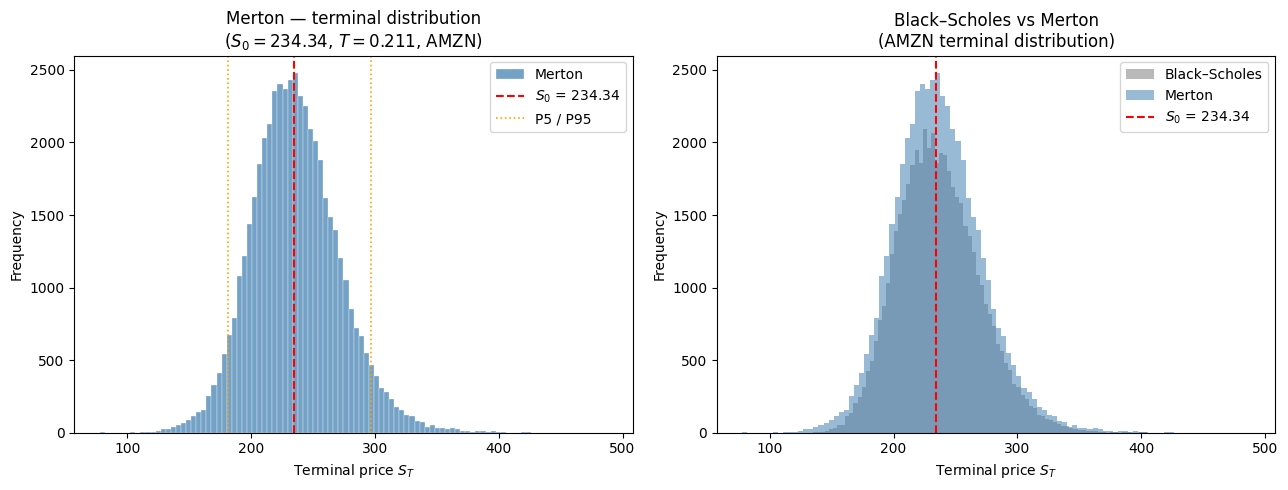


Statistics of $S_T$ under Merton (S0=234.34, T=0.211)
  Mean           : 236.11
  Median         : 234.16
  Std. deviation : 35.70
  Percentile  5% : 181.67
  Percentile 95% : 297.13
  Skewness       : 0.4084
  Kurtosis       : 0.9348


In [108]:
# Parámetros de la fecha inicial del proyecto
S0_plot = float(df_bs.loc[0, "S"])        # 234.34
T_plot  = float(df_bs.loc[0, "T"])        # 0.211
r_plot  = float(df_bs.loc[0, "r_cont"])   # 0.0417
sig_bs  = float(df_bs.loc[0, "sigma"])    # 0.3046

# Distribución BS
rng_plot = np.random.default_rng(0)
z_bs = rng_plot.standard_normal(50_000)
ST_bs = S0_plot * np.exp(
    (r_plot - 0.5 * sig_bs**2) * T_plot + sig_bs * np.sqrt(T_plot) * z_bs
)

# Distribución Merton
ST_merton = simulate_merton_terminal(
    S0=S0_plot, T=T_plot, r=r_plot,
    sigma=merton_params["sigma"],
    lambda_j=merton_params["lambda_j"],
    mu_j=merton_params["mu_j"],
    sigma_j=merton_params["sigma_j"],
    n_paths=50_000, seed=1,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: solo Merton con percentiles
ax = axes[0]
ax.hist(ST_merton, bins=100, color="steelblue", alpha=0.75,
        edgecolor="white", linewidth=0.3, label="Merton")
ax.axvline(S0_plot,                              color="red",    linestyle="--", lw=1.5, label=f"$S_0$ = {S0_plot}")
ax.axvline(np.percentile(ST_merton,  5),         color="orange", linestyle=":",  lw=1.2, label="P5 / P95")
ax.axvline(np.percentile(ST_merton, 95),         color="orange", linestyle=":",  lw=1.2)
ax.set_xlabel("Terminal price $S_T$")
ax.set_ylabel("Frequency")
ax.set_title(f"Merton — terminal distribution\n($S_0={S0_plot}$, $T={T_plot}$, AMZN)")

ax.legend()

# Panel derecho: BS vs Merton superpuestos
ax2 = axes[1]
ax2.hist(ST_bs,     bins=100, alpha=0.55, color="gray",      label="Black–Scholes")
ax2.hist(ST_merton, bins=100, alpha=0.55, color="steelblue", label="Merton")
ax2.axvline(S0_plot, color="red", linestyle="--", lw=1.5, label=f"$S_0$ = {S0_plot}")
ax2.set_xlabel("Terminal price $S_T$")
ax2.set_ylabel("Frequency")
ax2.set_title("Black–Scholes vs Merton\n(AMZN terminal distribution)")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nStatistics of $S_T$ under Merton (S0={S0_plot}, T={T_plot})")
print(f"  Mean           : {ST_merton.mean():,.2f}")
print(f"  Median         : {np.median(ST_merton):,.2f}")
print(f"  Std. deviation : {ST_merton.std():,.2f}")
print(f"  Percentile  5% : {np.percentile(ST_merton,  5):,.2f}")
print(f"  Percentile 95% : {np.percentile(ST_merton, 95):,.2f}")
print(f"  Skewness       : {float(pd.Series(ST_merton).skew()):,.4f}")
print(f"  Kurtosis       : {float(pd.Series(ST_merton).kurtosis()):,.4f}")

# Heston Method

## Theory

This section presents a methodology for valuing an option on a stock under stochastic volatility, based on the model proposed by Steven L. Heston in his article "A Closed-Form Solution for Options with Stochastic Volatility with Applications to Bond and Currency Options", published in *The Review of Financial Studies* in 1993.

A relevant aspect of Heston’s proposal is that he obtains the characteristic functions of the risk-neutral probabilities as solutions to a second-order partial differential equation.

The Black–Scholes model assumes that the asset price follows a geometric Brownian motion with constant volatility. Under this assumption, all uncertainty in the model comes from a single source of randomness, represented by the Brownian motion driving the underlying asset price. However, in practice, observed market volatility is not constant: it changes over time, exhibits persistence, clusters in periods of high and low uncertainty, and generates structures such as the implied volatility smile or skew.

The **Heston (1993)** model extends Black–Scholes by introducing a second state variable: the instantaneous variance of the asset. In other words, the underlying price remains stochastic, but now the intensity of its movements is also random. Therefore, the model does not only describe the evolution of the asset price $S_t$, but also the evolution of its variance $v_t = \sigma_t^2$.

Under the risk-neutral measure $\mathbb{Q}$, the dynamics of the model are written as:

$$
dS_t = (r-q)S_t\,dt + \sqrt{v_t}S_t\,dW_t^S
$$

$$
dv_t = \kappa(\theta-v_t)\,dt + \xi\sqrt{v_t}\,dW_t^v
$$

with:

$$
dW_t^S dW_t^v = \rho\,dt
$$

where the components are:

| Symbol | Description |
|---------|-------------|
| $S_t$ | Price of the underlying asset at time $t$ |
| $v_t=\sigma_t^2$ | Instantaneous variance of the asset |
| $r$ | Continuously compounded risk-free rate |
| $q$ | Continuous dividend yield, if applicable |
| $\kappa$ | Speed of mean reversion of variance toward its long-run mean |
| $\theta$ | Long-run level of variance |
| $\xi$ | Volatility of variance, also called *volatility of volatility* |
| $\rho$ | Correlation between price shocks and variance shocks |
| $W_t^S$ | Brownian motion associated with the asset price |
| $W_t^v$ | Brownian motion associated with the variance process |

The term $\kappa(\theta-v_t)$ introduces mean reversion. If the current variance $v_t$ is above its long-run level $\theta$, then the drift of the variance becomes negative and pushes it downward. If $v_t$ is below $\theta$, the drift becomes positive and pushes it upward.

On the other hand, the term $\xi\sqrt{v_t}dW_t^v$ introduces uncertainty into the variance itself. The square-root structure plays an important role because it prevents variance from behaving naturally as a normal variable that could take negative values. For this reason, the variance process in the Heston model has a **Cox–Ingersoll–Ross (CIR)** type structure.

---

### Relationship with the Ornstein–Uhlenbeck Process and CIR-Type Variance

An intuitive way to arrive at the Heston model is to start from a volatility process of the Ornstein–Uhlenbeck type:

$$
d\sigma_t=-\beta\sigma_tdt+\delta dU_t
$$

If we define variance as:

$$
v_t=\sigma_t^2
$$

then, by applying Itô’s lemma to $v_t=\sigma_t^2$, we obtain:

$$
dv_t=d(\sigma_t^2)=2\sigma_td\sigma_t+(d\sigma_t)^2
$$

Since:

$$
d\sigma_t=-\beta\sigma_tdt+\delta dU_t
$$

then:

$$
(d\sigma_t)^2=\delta^2dt
$$

therefore:

$$
dv_t=2\sigma_t(-\beta\sigma_tdt+\delta dU_t)+\delta^2dt
$$

$$
dv_t=(\delta^2-2\beta\sigma_t^2)dt+2\delta\sigma_tdU_t
$$

Since $v_t=\sigma_t^2$ and $\sigma_t=\sqrt{v_t}$, we obtain:

$$
dv_t=(\delta^2-2\beta v_t)dt+2\delta\sqrt{v_t}dU_t
$$

This expression can be rewritten as:

$$
dv_t=a(b-v_t)dt+\gamma\sqrt{v_t}dU_t
$$

where:

$$
a=2\beta
$$

$$
b=\frac{\delta^2}{2\beta}
$$

$$
\gamma=2\delta
$$

This is the mathematical intuition connecting Ornstein–Uhlenbeck-type volatility with the CIR-type variance process used by Heston.

---

### Application of Multivariable Itô’s Lemma

Under the Heston model, the price of an option depends on three variables:

$$
c=c(t,S_t,v_t)
$$

Unlike Black–Scholes, where the option depends only on the underlying asset price and time, here it also depends on instantaneous variance. Therefore, the multivariable version of Itô’s lemma must be applied:

$$
dc =
\frac{\partial c}{\partial t}dt
+\frac{\partial c}{\partial S_t}dS_t
+\frac{\partial c}{\partial v_t}dv_t
+\frac{1}{2}
\frac{\partial^2 c}{\partial S_t^2}
(dS_t)^2
+\frac{\partial^2 c}{\partial S_t\partial v_t}
dS_tdv_t
+\frac{1}{2}
\frac{\partial^2 c}{\partial v_t^2}
(dv_t)^2
$$

From the dynamics:

$$
dS_t=(r-q)S_tdt+\sqrt{v_t}S_tdW_t^S
$$

$$
dv_t=\kappa(\theta-v_t)dt+\xi\sqrt{v_t}dW_t^v
$$

the relevant quadratic products are:

$$
(dS_t)^2=v_tS_t^2dt
$$

$$
(dv_t)^2=\xi^2v_tdt
$$

$$
dS_tdv_t=\rho\xi v_tS_tdt
$$

Substituting into Itô’s lemma:

$$
dc =
\left[
\frac{\partial c}{\partial t}
+
(r-q)S_t\frac{\partial c}{\partial S_t}
+
\kappa(\theta-v_t)\frac{\partial c}{\partial v_t}
+
\frac{1}{2}v_tS_t^2\frac{\partial^2 c}{\partial S_t^2}
+
\rho\xi v_tS_t\frac{\partial^2 c}{\partial S_t\partial v_t}
+
\frac{1}{2}\xi^2v_t\frac{\partial^2 c}{\partial v_t^2}
\right]dt
+
\sqrt{v_t}S_t\frac{\partial c}{\partial S_t}dW_t^S
+
\xi\sqrt{v_t}\frac{\partial c}{\partial v_t}dW_t^v
$$

This expression shows that the option value is exposed to two sources of uncertainty: the shock to the underlying asset price and the shock to variance. The cross term

$$
\rho\xi v_tS_t\frac{\partial^2 c}{\partial S_t\partial v_t}
$$

appears because price movements and variance movements may be correlated. This point is crucial: if $\rho<0$, a decrease in the asset price tends to be associated with an increase in volatility, which helps capture part of the skew observed in market implied volatility.

---

### Pricing Partial Differential Equation

Under risk neutrality, the option price must satisfy a partial differential equation. If the variance parameters are already expressed under the risk-neutral measure $\mathbb{Q}$, the Heston PDE for a derivative $c(t,S_t,v_t)$ is:

$$
\frac{\partial c}{\partial t}
+
(r-q)S_t\frac{\partial c}{\partial S_t}
+
\kappa(\theta-v_t)\frac{\partial c}{\partial v_t}
+
\frac{1}{2}v_tS_t^2\frac{\partial^2 c}{\partial S_t^2}
+
\rho\xi v_tS_t\frac{\partial^2 c}{\partial S_t\partial v_t}
+
\frac{1}{2}\xi^2v_t\frac{\partial^2 c}{\partial v_t^2}-rc=0
$$

with terminal condition for a European call:

$$
c(T,S_T,v_T)=\max(S_T-K,0)
$$

The main difference relative to Black–Scholes is that the PDE now has two stochastic state variables: $S_t$ and $v_t$. Therefore, derivatives with respect to $S_t$, derivatives with respect to $v_t$, and a cross derivative between both variables appear in the equation.

---

### Semi-Analytical Pricing Form

One of the main advantages of the Heston model is that the price of a European option can be written in a form similar to Black–Scholes:

$$
C^{\text{Heston}}(S_0,K,T)=S_0e^{-qT}P_1-Ke^{-rT}P_2
$$

where $P_1$ and $P_2$ are adjusted probabilities under the risk-neutral measure. In Black–Scholes, these probabilities are calculated using the cumulative normal functions $N(d_1)$ and $N(d_2)$. In Heston, however, they are obtained through characteristic functions and Fourier inversion.

In general:

$$
P_j=\frac{1}{2}+
\frac{1}{\pi}
\int_0^\infty
\text{Re}
\left[
\frac{e^{-iu\ln(K)}\varphi_j(u)}{iu}
\right]du,
\qquad j=1,2
$$

where $\varphi_j(u)$ represents the characteristic function corresponding to each adjusted probability. Therefore, Heston does not completely eliminate numerical methods, but it reduces the problem to evaluating one-dimensional integrals instead of directly solving a two-dimensional PDE.

---

### Model Parameters and Values Used in the Project

The five main parameters of the model have a direct economic interpretation:

| Parameter | Description | Value used in the project |
|-----------|-------------|-----------------------------|
| $v_0$ | Initial variance of the asset | Estimated from the initial or implied volatility |
| $\theta$ | Long-run variance | Historical average or average squared implied volatility |
| $\kappa$ | Speed of mean reversion | Calibrated parameter or reference assumption |
| $\xi$ | Volatility of variance | Calibrated parameter or reference assumption |
| $\rho$ | Price-variance correlation | Calibrated parameter or reference assumption, usually negative in equity |

In the context of this project, the Heston model complements three previous approaches:

1. Black–Scholes with fixed historical volatility.
2. Black–Scholes with implied volatility.
3. Merton Jump–Diffusion with jump risk.

While Merton seeks to capture extreme discrete movements through jumps, Heston seeks to capture the continuous dynamics of volatility. Therefore, Heston is especially useful when the main market distortion does not come only from extreme events, but from an implied volatility surface that changes across strikes and maturities.

---

### Monte Carlo Valuation

Although Heston has a semi-analytical solution based on characteristic functions, it can also be valued using Monte Carlo simulation. This approach is methodologically useful because it allows us to directly observe the joint evolution of the asset price and variance.

For each simulated path, two correlated normal variables are generated:

$$
Z_v=\rho Z_S+\sqrt{1-\rho^2}Z_{\perp}
$$

where:

$$
Z_S\sim \mathcal{N}(0,1),
\qquad
Z_{\perp}\sim \mathcal{N}(0,1)
$$

and both are independent.

Using an Euler discretization with truncation to avoid negative variance:

$$
v_{t+\Delta t}=
\max
\left(
v_t+\kappa(\theta-v_t)\Delta t+\xi\sqrt{v_t}\sqrt{\Delta t}Z_v,
0
\right)
$$

and the price is updated as:

$$
S_{t+\Delta t}=S_t
\exp
\left[
\left(r-q-\frac{1}{2}v_t\right)\Delta t
+
\sqrt{v_t}\sqrt{\Delta t}Z_S
\right]
$$

At the end of each path, the payoff is calculated as:

$$
\max(S_T-K,0)
$$

and the call price is estimated as the discounted average:

$$
\hat{C}^{\text{Heston}}
=
e^{-rT}
\frac{1}{M}
\sum_{i=1}^{M}
\max(S_T^{(i)}-K,0)
$$

where $M$ is the total number of simulated paths.

---

### Heston vs Black–Scholes Comparison

The comparison between Heston and Black–Scholes allows us to measure the additional premium that arises from allowing stochastic volatility. The absolute difference is defined as:

$$
C^{\text{Heston}}-C^{\text{BS}}
$$

Positive values indicate that Heston assigns a higher value to the option than Black–Scholes. This may occur because stochastic volatility introduces greater uncertainty into the terminal distribution of the asset price, especially when volatility of volatility is high or when price-variance correlation is negative.

The relative difference is calculated as:

$$
\frac{C^{\text{Heston}}-C^{\text{BS}}}{C^{\text{BS}}}
$$

This metric allows us to evaluate which strikes or dates are more affected by the constant-volatility assumption relative to a model with dynamic variance.

---

### Heston vs Market Comparison

The key model-quality metric is the difference between the price estimated by Heston and the observed market price:

$$
C^{\text{Heston}}-C^{\text{Market}}
$$

A positive error indicates that Heston overvalues the option relative to the market, while a negative error indicates that it undervalues it. To evaluate the aggregate performance of the model, the following metrics are used:

$$
MAE=\frac{1}{n}\sum_{i=1}^{n}\left|C_i^{\text{Heston}}-C_i^{\text{Market}}\right|
$$

$$
RMSE=
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
\left(C_i^{\text{Heston}}-C_i^{\text{Market}}\right)^2
}
$$

$$
Bias=
\frac{1}{n}
\sum_{i=1}^{n}
\left(C_i^{\text{Heston}}-C_i^{\text{Market}}\right)
$$

MAE measures the average absolute error, RMSE penalizes large errors more strongly, and bias allows us to identify whether the model systematically tends to overvalue or undervalue the options.

---

### Terminal Distribution under Heston

Path simulation allows us to compare the terminal distribution of $S_T$ under Black–Scholes, Merton, and Heston.

Under Black–Scholes, volatility is constant, so terminal dispersion depends only on $\sigma$ and time to maturity. Under Merton, the distribution incorporates discrete jumps, generating heavier tails. Under Heston, the terminal distribution arises from a volatility process that changes throughout the life of the option.

Therefore, Heston may generate heavier tails, asymmetry, and changes in the shape of the terminal distribution, especially when $\rho$ is negative and $\xi$ is high. This helps explain why options with different strikes may require different implied volatilities, even when they have the same maturity.

In summary, Heston does not replace Black–Scholes merely by adding mathematical complexity; it extends it to capture a central feature of real markets: volatility is not constant, but rather dynamic, persistent, and correlated with the asset price.

In [109]:
# Parámetros base del modelo de Heston

# Varianza inicial: se toma de la volatilidad observada en la primera fecha del proyecto
v0_base = float(df_bs.loc[0, "sigma"] ** 2)

# Varianza de largo plazo: promedio de las varianzas históricas / implícitas usadas en df_bs
theta_base = float((df_bs["sigma"] ** 2).mean())

# Parámetros Heston — valores de referencia para implementación inicial
# Estos parámetros pueden calibrarse posteriormente contra precios de mercado.
heston_params = {
    "v0"    : v0_base,      # varianza inicial
    "theta" : theta_base,   # varianza de largo plazo
    "kappa" : 2.0,          # velocidad de reversión a la media
    "xi"    : 0.50,         # volatilidad de la varianza
    "rho"   : -0.70,        # correlación precio-varianza
    "q"     : 0.00          # dividend yield continuo, si no aplica se mantiene en cero
}

print("Heston parameters")
print("-" * 40)
for key, value in heston_params.items():
    print(f"{key:>6}: {value:.6f}")

Heston parameters
----------------------------------------
    v0: 0.092781
 theta: 0.085108
 kappa: 2.000000
    xi: 0.500000
   rho: -0.700000
     q: 0.000000


In [110]:
def simulate_heston_terminal(
    S0, T, r,
    v0, theta, kappa, xi, rho,
    q=0.0,
    n_paths=50_000,
    steps_per_year=252,
    seed=42
):
    """
    Simula precios terminales S_T bajo el modelo de Heston.

    Dinámica neutral al riesgo:

        dS_t = (r - q) S_t dt + sqrt(v_t) S_t dW_t^S

        dv_t = kappa(theta - v_t) dt + xi sqrt(v_t) dW_t^v

        corr(dW_t^S, dW_t^v) = rho

    Se usa Euler con truncamiento completo:
        v_pos = max(v_t, 0)

    Esto evita que la simulación genere varianzas negativas.
    """

    rng = np.random.default_rng(seed)

    n_steps = max(1, int(np.ceil(steps_per_year * T)))
    dt = T / n_steps

    S = np.full(n_paths, S0, dtype=float)
    v = np.full(n_paths, v0, dtype=float)

    for _ in range(n_steps):

        z_s = rng.standard_normal(n_paths)
        z_ind = rng.standard_normal(n_paths)

        z_v = rho * z_s + np.sqrt(1 - rho**2) * z_ind

        v_pos = np.maximum(v, 0)

        # Actualización lognormal del precio
        S = S * np.exp(
            (r - q - 0.5 * v_pos) * dt
            + np.sqrt(v_pos * dt) * z_s
        )

        # Actualización Euler de la varianza
        v = (
            v
            + kappa * (theta - v_pos) * dt
            + xi * np.sqrt(v_pos * dt) * z_v
        )

        # Truncamiento para mantener varianza no negativa
        v = np.maximum(v, 0)

    return S

In [111]:
def heston_call_price_from_terminal(ST, K, T, r):
    """
    Calcula el precio de una opción call europea usando precios terminales simulados.
    También reporta el error estándar de Monte Carlo.
    """
    payoff = np.maximum(ST - K, 0)
    discounted_payoff = np.exp(-r * T) * payoff

    price = discounted_payoff.mean()
    se = discounted_payoff.std(ddof=1) / np.sqrt(len(discounted_payoff))

    return price, se

In [112]:
def heston_call_price_table(
    df_bs,
    df_K,
    params,
    n_paths=50_000,
    steps_per_year=252,
    seed=42,
    time_col="fecha_obs"
):
    """
    Construye una tabla de precios call bajo Heston para cada combinación fecha × strike.

    Usa la misma estructura que las tablas de Black–Scholes y Merton:
        índice  -> K
        columnas -> fecha
        valores -> precio Heston
    """

    theta = params["theta"]
    kappa = params["kappa"]
    xi = params["xi"]
    rho = params["rho"]
    q = params.get("q", 0.0)

    records = []

    for i, row in df_bs.iterrows():

        S0 = float(row["S"])
        T = float(row["T"])
        r = float(row["r_cont"])
        fecha = pd.to_datetime(row[time_col]).strftime("%Y-%m-%d")

        # Varianza inicial específica de cada fecha
        v0 = float(row["sigma"] ** 2)

        ST = simulate_heston_terminal(
            S0=S0,
            T=T,
            r=r,
            v0=v0,
            theta=theta,
            kappa=kappa,
            xi=xi,
            rho=rho,
            q=q,
            n_paths=n_paths,
            steps_per_year=steps_per_year,
            seed=seed + i
        )

        for _, krow in df_K.iterrows():
            K = float(krow["K"])

            price, se = heston_call_price_from_terminal(
                ST=ST,
                K=K,
                T=T,
                r=r
            )

            records.append({
                "fecha": fecha,
                "K": K,
                "heston_price": price,
                "se": se
            })

    df_long = pd.DataFrame(records)

    tabla = (
        df_long
        .pivot(index="K", columns="fecha", values="heston_price")
        .sort_index()
        .round(2)
    )

    return tabla

In [113]:
tabla_heston = heston_call_price_table(
    df_bs=df_bs,
    df_K=df_K,
    params=heston_params,
    n_paths=50_000,
    steps_per_year=252,
    seed=42
)

tabla_heston

fecha,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
K,,,,,,,,,,,,,
140.0,95.72,103.13,83.75,67.81,61.92,65.03,69.18,68.56,79.49,73.82,69.62,71.96,67.78
170.0,66.29,73.53,54.21,38.78,32.87,35.74,39.66,38.99,49.68,43.91,39.71,42.01,37.83
195.0,42.92,49.55,31.02,17.87,12.74,14.71,17.61,16.87,25.84,19.87,16.00,17.63,13.78
212.5,28.30,34.04,17.30,7.65,4.19,5.17,6.81,6.21,12.10,6.90,4.46,4.80,2.73
227.5,17.80,22.41,8.54,2.73,1.01,1.33,2.00,1.66,4.45,1.46,0.65,0.60,0.20
235.0,13.47,17.40,5.44,1.43,0.41,0.55,0.89,0.70,2.28,0.49,0.16,0.13,0.03
252.5,6.03,8.36,1.35,0.22,0.03,0.04,0.07,0.05,0.28,0.01,0.00,0.00,0.00
270.0,2.07,3.12,0.21,0.02,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00
280.0,0.98,1.55,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [114]:
# Precios Black–Scholes en la misma convención de columnas
tabla_bs_raw = call_premium_table(df_bs, df_K)

tabla_bs_fmt = tabla_bs_raw.copy()
tabla_bs_fmt.columns = [
    pd.to_datetime(c).strftime("%Y-%m-%d") for c in tabla_bs_fmt.columns
]

# Alinear tabla BS con tabla Heston
tabla_bs_idx = tabla_bs_fmt.reindex(
    index=tabla_heston.index,
    columns=tabla_heston.columns
)

tabla_heston

fecha,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
K,,,,,,,,,,,,,
140.0,95.72,103.13,83.75,67.81,61.92,65.03,69.18,68.56,79.49,73.82,69.62,71.96,67.78
170.0,66.29,73.53,54.21,38.78,32.87,35.74,39.66,38.99,49.68,43.91,39.71,42.01,37.83
195.0,42.92,49.55,31.02,17.87,12.74,14.71,17.61,16.87,25.84,19.87,16.00,17.63,13.78
212.5,28.30,34.04,17.30,7.65,4.19,5.17,6.81,6.21,12.10,6.90,4.46,4.80,2.73
227.5,17.80,22.41,8.54,2.73,1.01,1.33,2.00,1.66,4.45,1.46,0.65,0.60,0.20
235.0,13.47,17.40,5.44,1.43,0.41,0.55,0.89,0.70,2.28,0.49,0.16,0.13,0.03
252.5,6.03,8.36,1.35,0.22,0.03,0.04,0.07,0.05,0.28,0.01,0.00,0.00,0.00
270.0,2.07,3.12,0.21,0.02,0.00,0.00,0.00,0.00,0.01,0.00,0.00,0.00,0.00
280.0,0.98,1.55,0.06,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


In [115]:
diff_heston_bs = (tabla_heston - tabla_bs_idx).round(4)
diff_heston_bs

fecha,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
K,,,,,,,,,,,,,
140.0,0.15,0.28,0.05,-0.08,-0.05,-0.19,-0.08,-0.03,-0.01,-0.05,0.10,0.01,0.02
170.0,0.37,0.42,0.24,0.27,0.28,0.09,0.11,0.14,0.05,-0.04,0.11,0.01,0.02
195.0,0.72,0.75,0.66,0.21,0.08,0.10,0.25,0.26,0.31,0.17,0.28,0.15,0.16
212.5,0.61,0.86,0.48,-0.46,-0.55,-0.49,-0.29,-0.27,0.13,-0.06,-0.08,-0.02,-0.11
227.5,0.08,0.54,-0.17,-0.80,-0.63,-0.66,-0.58,-0.56,-0.36,-0.32,-0.25,-0.16,-0.11
235.0,-0.27,0.23,-0.49,-0.78,-0.48,-0.54,-0.54,-0.48,-0.48,-0.27,-0.16,-0.10,-0.04
252.5,-0.98,-0.59,-0.75,-0.42,-0.15,-0.18,-0.22,-0.17,-0.31,-0.06,-0.02,-0.01,0.00
270.0,-1.14,-1.00,-0.40,-0.14,-0.03,-0.04,-0.05,-0.03,-0.08,0.00,0.00,0.00,0.00
280.0,-0.98,-0.96,-0.22,-0.07,-0.01,-0.01,-0.01,-0.01,-0.03,0.00,0.00,0.00,0.00


In [116]:
# Diferencia relativa Heston vs Black–Scholes (%)
diff_heston_bs_pct = (
    (tabla_heston - tabla_bs_idx) / tabla_bs_idx.abs() * 100
).round(2)

diff_heston_bs_pct

fecha,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
K,,,,,,,,,,,,,
140.0,0.16,0.27,0.06,-0.12,-0.08,-0.29,-0.12,-0.04,-0.01,-0.07,0.14,0.01,0.03
170.0,0.56,0.57,0.44,0.70,0.86,0.25,0.28,0.36,0.10,-0.09,0.28,0.02,0.05
195.0,1.71,1.54,2.17,1.19,0.63,0.68,1.44,1.57,1.21,0.86,1.78,0.86,1.17
212.5,2.20,2.59,2.85,-5.67,-11.60,-8.66,-4.08,-4.17,1.09,-0.86,-1.76,-0.41,-3.87
227.5,0.45,2.47,-1.95,-22.66,-38.41,-33.17,-22.48,-25.23,-7.48,-17.98,-27.78,-21.05,-35.48
235.0,-1.97,1.34,-8.26,-35.29,-53.93,-49.54,-37.76,-40.68,-17.39,-35.53,-50.00,-43.48,-57.14
252.5,-13.98,-6.59,-35.71,-65.62,-83.33,-81.82,-75.86,-77.27,-52.54,-85.71,-100.00,-100.00,NaN
270.0,-35.51,-24.27,-65.57,-87.50,-100.00,-100.00,-100.00,-100.00,-88.89,NaN,NaN,NaN,NaN
280.0,-50.00,-38.25,-78.57,-100.00,-100.00,-100.00,-100.00,-100.00,-100.00,NaN,NaN,NaN,NaN


In [117]:
# Alinear tabla de mercado con tabla Heston
tabla_mercado_heston = tabla_mercado.reindex(
    index=tabla_heston.index,
    columns=tabla_heston.columns
)

diff_heston_market = (tabla_heston - tabla_mercado_heston).round(4)
diff_heston_market

fecha,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
K,,,,,,,,,,,,,
140.0,-20.405,-0.945,-1.850,-1.990,-1.555,-1.970,-1.870,0.610,0.565,NaN,0.845,0.260,0.080
170.0,-20.535,-1.895,-3.665,-3.420,-4.155,-3.885,-3.415,1.065,0.180,0.060,0.860,0.310,-0.370
195.0,-20.855,-3.475,-6.755,-5.280,-6.710,-6.540,-6.265,4.245,1.840,1.470,2.100,0.905,0.930
212.5,-14.100,NaN,NaN,NaN,NaN,NaN,NaN,6.015,5.375,4.430,4.085,3.020,2.485
227.5,-4.275,NaN,NaN,NaN,NaN,NaN,NaN,1.645,4.405,1.445,0.645,0.575,0.195
235.0,-1.280,-6.875,-9.585,-4.770,-4.290,-4.575,-5.260,0.695,2.275,0.485,0.155,0.115,0.025
252.5,1.180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
270.0,0.590,-6.430,-4.915,-1.680,-1.275,-1.255,-1.455,-0.005,-0.010,-0.020,-0.005,-0.005,-0.005
280.0,-0.080,-5.525,-3.590,-1.210,-0.920,-0.850,-0.980,-0.025,-0.015,-0.030,-0.005,-0.025,-0.120


In [118]:
# Error porcentual Heston vs Mercado (%)
diff_heston_market_pct = (
    diff_heston_market / tabla_mercado_heston.abs() * 100
).round(2)

diff_heston_market_pct

fecha,2026-01-22,2026-01-29,2026-02-05,2026-02-10,2026-02-17,2026-02-19,2026-02-24,2026-02-26,2026-03-05,2026-03-17,2026-03-19,2026-03-25,2026-03-26
K,,,,,,,,,,,,,
140.0,-17.57,-0.91,-2.16,-2.85,-2.45,-2.94,-2.63,0.90,0.72,NaN,1.23,0.36,0.12
170.0,-23.65,-2.51,-6.33,-8.10,-11.22,-9.80,-7.93,2.81,0.36,0.14,2.21,0.74,-0.97
195.0,-32.70,-6.55,-17.88,-22.81,-34.50,-30.78,-26.24,33.62,7.67,7.99,15.11,5.41,7.24
212.5,-33.25,NaN,NaN,NaN,NaN,NaN,NaN,3084.62,79.93,179.35,1089.33,169.66,1014.29
227.5,-19.37,NaN,NaN,NaN,NaN,NaN,NaN,10966.67,9788.89,9633.33,12900.00,2300.00,3900.00
235.0,-8.68,-28.32,-63.79,-76.94,-91.28,-89.27,-85.53,13900.00,45500.00,9700.00,3100.00,766.67,500.00
252.5,24.33,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
270.0,39.86,-67.33,-95.90,-98.82,-100.00,-100.00,-100.00,-100.00,-50.00,-100.00,-100.00,-100.00,-100.00
280.0,-7.55,-78.09,-98.36,-100.00,-100.00,-100.00,-100.00,-100.00,-100.00,-100.00,-100.00,-100.00,-100.00


In [119]:
# Solo errores donde hay precio de mercado disponible
errors_heston_flat = diff_heston_market.stack().dropna()
abs_errors_heston = errors_heston_flat.abs()

mae_heston = abs_errors_heston.mean()
rmse_heston = np.sqrt((errors_heston_flat ** 2).mean())
bias_heston = errors_heston_flat.mean()

# Error porcentual sobre precios con mercado disponible
pct_heston_flat = diff_heston_market_pct.stack().dropna()
mape_heston = pct_heston_flat.abs().mean()

print("Heston Stochastic Volatility — error de valoración vs Base0904")
print("-" * 62)
print(f"  MAE   : {mae_heston:.4f}")
print(f"  RMSE  : {rmse_heston:.4f}")
print(f"  MAPE  : {mape_heston:.2f}%")
print(f"  Sesgo : {bias_heston:+.4f}  (+ sobrevalora, − infravalora)")
print(f"  N obs : {len(errors_heston_flat)}")

Heston Stochastic Volatility — error de valoración vs Base0904
--------------------------------------------------------------
  MAE   : 2.4779
  RMSE  : 4.5229
  MAPE  : 1155.68%
  Sesgo : -1.5095  (+ sobrevalora, − infravalora)
  N obs : 116


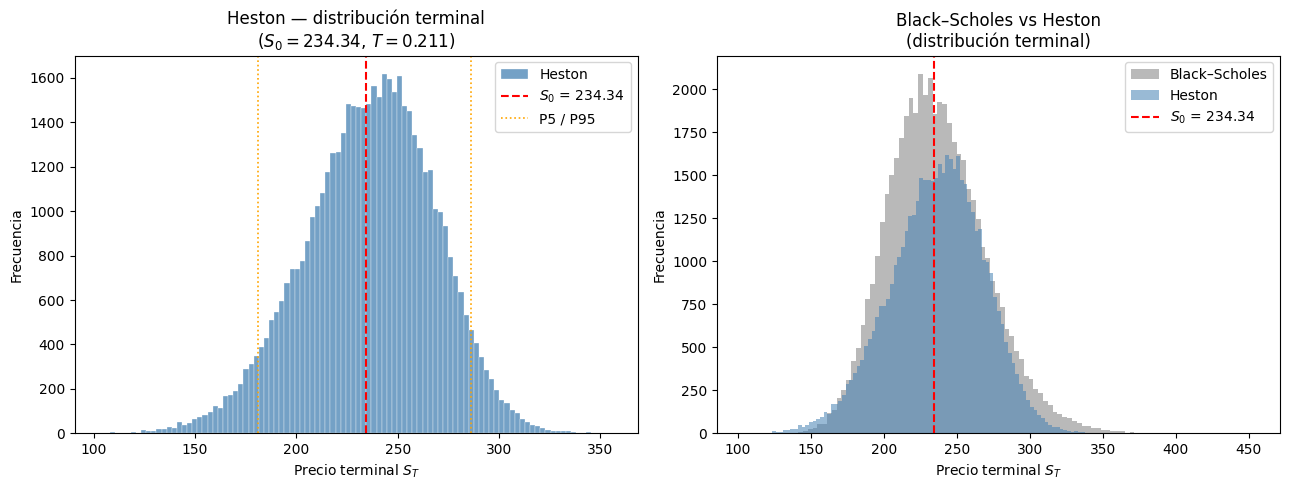


Estadísticas de $S_T$ bajo Heston (S0=234.34, T=0.211)
----------------------------------------------------------
  Media          : 236.44
  Mediana        : 238.14
  Desv. estándar : 32.03
  Percentil  5%  : 181.26
  Percentil 95%  : 286.13
  Sesgo (skew)   : -0.2447
  Curtosis       : 0.0501


In [120]:
# Parámetros de la fecha inicial del proyecto
S0_plot = float(df_bs.loc[0, "S"])
T_plot = float(df_bs.loc[0, "T"])
r_plot = float(df_bs.loc[0, "r_cont"])
sig_bs = float(df_bs.loc[0, "sigma"])

# Distribución terminal bajo Black–Scholes
rng_plot = np.random.default_rng(0)

z_bs = rng_plot.standard_normal(50_000)

ST_bs = S0_plot * np.exp(
    (r_plot - 0.5 * sig_bs**2) * T_plot
    + sig_bs * np.sqrt(T_plot) * z_bs
)

# Distribución terminal bajo Heston
ST_heston = simulate_heston_terminal(
    S0=S0_plot,
    T=T_plot,
    r=r_plot,
    v0=float(sig_bs**2),
    theta=heston_params["theta"],
    kappa=heston_params["kappa"],
    xi=heston_params["xi"],
    rho=heston_params["rho"],
    q=heston_params["q"],
    n_paths=50_000,
    steps_per_year=252,
    seed=1
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel izquierdo: solo Heston con percentiles
ax = axes[0]

ax.hist(
    ST_heston,
    bins=100,
    color="steelblue",
    alpha=0.75,
    edgecolor="white",
    linewidth=0.3,
    label="Heston"
)

ax.axvline(
    S0_plot,
    color="red",
    linestyle="--",
    lw=1.5,
    label=f"$S_0$ = {S0_plot:.2f}"
)

ax.axvline(
    np.percentile(ST_heston, 5),
    color="orange",
    linestyle=":",
    lw=1.2,
    label="P5 / P95"
)

ax.axvline(
    np.percentile(ST_heston, 95),
    color="orange",
    linestyle=":",
    lw=1.2
)

ax.set_xlabel("Precio terminal $S_T$")
ax.set_ylabel("Frecuencia")
ax.set_title(f"Heston — distribución terminal\n($S_0={S0_plot:.2f}$, $T={T_plot:.3f}$)")
ax.legend()

# Panel derecho: BS vs Heston
ax2 = axes[1]

ax2.hist(
    ST_bs,
    bins=100,
    alpha=0.55,
    color="gray",
    label="Black–Scholes"
)

ax2.hist(
    ST_heston,
    bins=100,
    alpha=0.55,
    color="steelblue",
    label="Heston"
)

ax2.axvline(
    S0_plot,
    color="red",
    linestyle="--",
    lw=1.5,
    label=f"$S_0$ = {S0_plot:.2f}"
)

ax2.set_xlabel("Precio terminal $S_T$")
ax2.set_ylabel("Frecuencia")
ax2.set_title("Black–Scholes vs Heston\n(distribución terminal)")
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nEstadísticas de $S_T$ bajo Heston (S0={S0_plot:.2f}, T={T_plot:.3f})")
print("-" * 58)
print(f"  Media          : {ST_heston.mean():,.2f}")
print(f"  Mediana        : {np.median(ST_heston):,.2f}")
print(f"  Desv. estándar : {ST_heston.std():,.2f}")
print(f"  Percentil  5%  : {np.percentile(ST_heston, 5):,.2f}")
print(f"  Percentil 95%  : {np.percentile(ST_heston, 95):,.2f}")
print(f"  Sesgo (skew)   : {float(pd.Series(ST_heston).skew()):,.4f}")
print(f"  Curtosis       : {float(pd.Series(ST_heston).kurtosis()):,.4f}")

<Figure size 1000x800 with 0 Axes>

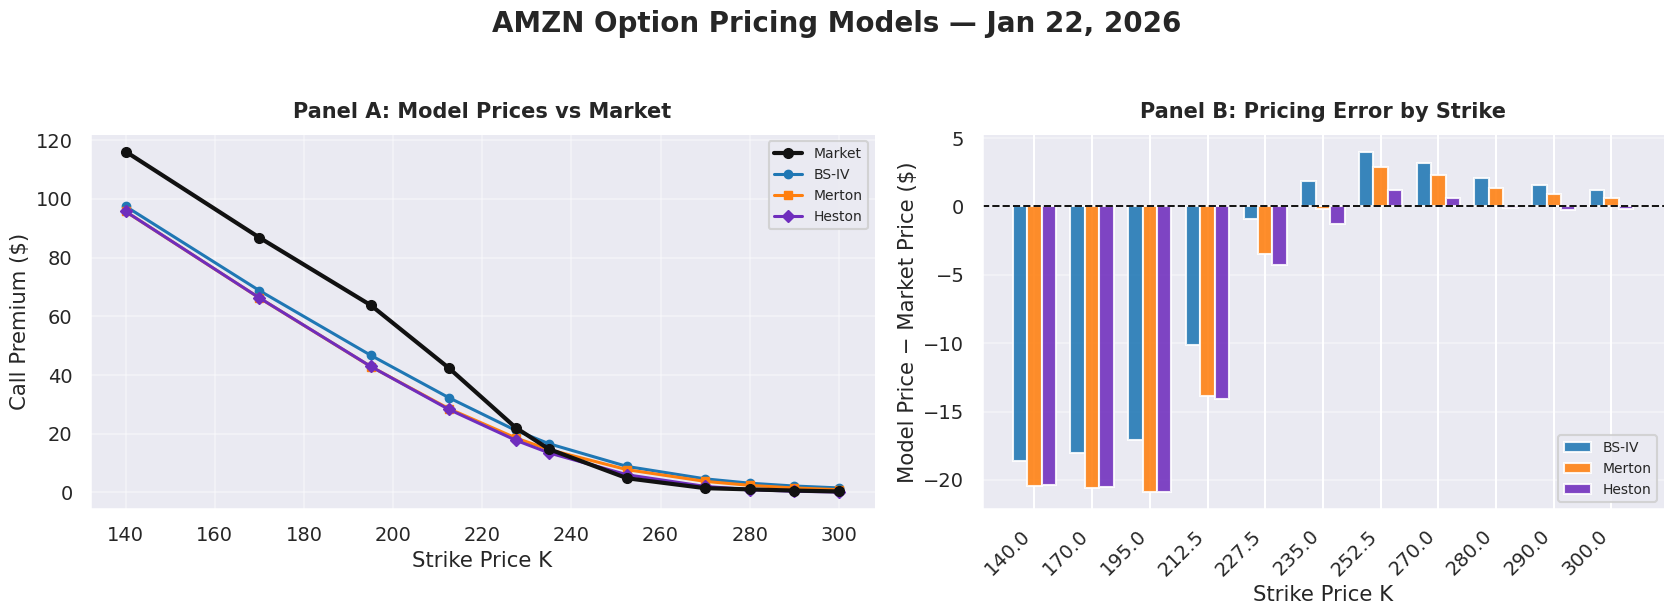

In [123]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# Style
# ============================================================

plt.figure(figsize=(10,8))

sns.set_theme(
    style="darkgrid",
    context="talk",
    font_scale=0.85
)

palette = {
    "Market": "#111111",   # black
    "BS-IV": "#1f77b4",    # blue
    "Merton": "#ff7f0e",   # orange
    "Heston": "#6f2dbd"    # purple
}

# ============================================================
# Data selection
# ============================================================

fecha_plot = "2026-01-22"

market = tabla_mercado[fecha_plot]
bs_iv = tabla_bs_iv[fecha_plot]
merton = tabla_merton[fecha_plot]
heston = tabla_heston[fecha_plot]

df_plot = pd.DataFrame({
    "Market": market,
    "BS-IV": bs_iv,
    "Merton": merton,
    "Heston": heston
}).dropna()

df_error = pd.DataFrame({
    "BS-IV": df_plot["BS-IV"] - df_plot["Market"],
    "Merton": df_plot["Merton"] - df_plot["Market"],
    "Heston": df_plot["Heston"] - df_plot["Market"]
})

# ============================================================
# Figure
# ============================================================

fig, axes = plt.subplots(
    1, 2,
    figsize=(17, 6),
    gridspec_kw={"width_ratios": [1.15, 1]}
)

fig.suptitle(
    "AMZN Option Pricing Models — Jan 22, 2026",
    fontsize=20,
    fontweight="bold",
    y=1.03
)

# ============================================================
# Panel A: Prices by strike
# ============================================================

ax = axes[0]

ax.plot(
    df_plot.index,
    df_plot["Market"],
    marker="o",
    markersize=7,
    linewidth=3.0,
    color=palette["Market"],
    label="Market",
    zorder=5
)

ax.plot(
    df_plot.index,
    df_plot["BS-IV"],
    marker="o",
    markersize=6,
    linewidth=2.2,
    color=palette["BS-IV"],
    label="BS-IV"
)

ax.plot(
    df_plot.index,
    df_plot["Merton"],
    marker="s",
    markersize=6,
    linewidth=2.2,
    color=palette["Merton"],
    label="Merton"
)

ax.plot(
    df_plot.index,
    df_plot["Heston"],
    marker="D",
    markersize=6,
    linewidth=2.2,
    color=palette["Heston"],
    label="Heston"
)

ax.set_title(
    "Panel A: Model Prices vs Market",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Strike Price K")
ax.set_ylabel("Call Premium ($)")
ax.legend(frameon=True, fontsize=10)
ax.grid(True, alpha=0.35)

# ============================================================
# Panel B: Pricing errors by strike
# ============================================================

ax = axes[1]

x = np.arange(len(df_error.index))
width = 0.25

ax.bar(
    x - width,
    df_error["BS-IV"],
    width,
    color=palette["BS-IV"],
    label="BS-IV",
    alpha=0.88
)

ax.bar(
    x,
    df_error["Merton"],
    width,
    color=palette["Merton"],
    label="Merton",
    alpha=0.88
)

ax.bar(
    x + width,
    df_error["Heston"],
    width,
    color=palette["Heston"],
    label="Heston",
    alpha=0.88
)

ax.axhline(
    0,
    color="#111111",
    linewidth=1.4,
    linestyle="--"
)

ax.set_title(
    "Panel B: Pricing Error by Strike",
    fontsize=15,
    fontweight="bold",
    pad=12
)

ax.set_xlabel("Strike Price K")
ax.set_ylabel("Model Price − Market Price ($)")
ax.set_xticks(x)
ax.set_xticklabels(df_error.index, rotation=45, ha="right")
ax.legend(frameon=True, fontsize=10)
ax.grid(True, axis="y", alpha=0.35)

# ============================================================
# Final formatting
# ============================================================

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()

# Save for Overleaf
plt.savefig(
    "amzn_model_comparison_darkgrid.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()